# 08 — Hydrogen combustion acceleration (Sec. III B)

The main results compare **H0** (primary random initialization) with **Hnorm1**
(norm-matched initialization), in paper order: **Figure 7 → Figure 8A → Figure 8B → Table I**.
Each model has one Figure 7; the H0 failure diagnostics are collected in the appendix.
[Jump to the comparison](#hydrogen-initialization-comparison).

Hnorm1 has lower held-out trajectory MSE (0.2088 vs 3.1461) and lower 441-grid median
MSE (0.2536 vs 2.6576). It ignites in all 30 reference-igniting cases, but also in two
cases where the reference does not. It is a better result among these two evaluated
N=4/base-ON runs, not an established best initialization across seeds. H0 remains the
primary reproduction attempt; both use 344 parameters and direct autograd rather than FSA.

**Display scaling:** Figure 7 uses explicitly labelled species display multipliers; these
change only the displayed mass fractions, not the predictions or losses. Figure 8A shows
the requested paper-sized MSE scale and a separate full-range comparison, both with
lower errors darker and one shared scale for H0 and Hnorm1. Matching
the paper's layout does not imply matching its numerical error range.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "chemkan" / "src"))
sys.path.insert(0, str(ROOT / "chemkan" / "scripts"))
# Every paper figure is generated by chemkan/scripts/figures/*.py; this notebook only
# supplies run paths and interprets the results.
sys.path.insert(0, str(ROOT / "chemkan" / "scripts" / "figures"))

from chemkan.normalization import MinMaxNormalizer
from evaluate_hydrogen import build_chemkan, solver_from_ckpt, integrate_hydrogen
from _data import load_input_scaling

# PRIMARY reproduction attempt: N=4 / base-ON, 344 parameters, default (random) thermo init.
# It completed 10,000 Stage-2 epochs and FAILS to ignite; it is kept as the baseline anyway.
_HYD = ROOT / "results/reproduction/chemkan/hydrogen/diagnostics/base_on_n4"
RUN_DIR    = _HYD / "random_stage2_10000_seed0"          # H0
STAGE1_DIR = _HYD / "stage1_seed0"                       # H1: the shared Stage-1 branch point
COMPARE_DIR = _HYD / "normmatched_dir1_stage2_10000"     # Hnorm1: labelled init comparison
# Historical N=5 / base-OFF run, kept under its own label and NOT the primary any more.
HISTORICAL_RUN_DIR = ROOT / "results/reproduction/chemkan/hydrogen/main/base_off_direct_autograd_seed0"
FIG_DIR   = ROOT / "results/reproduction/figures/hydrogen"
TABLE_DIR = ROOT / "results/reproduction/tables"
SAVE_FIGURES, SAVE_TABLES = True, True
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

npz = np.load(ROOT / "chemkan/data/generated/hydrogen.npz", allow_pickle=True)
t, ics, states = npz["t"], npz["ics"], npz["states"]
species = [str(s) for s in npz["species"]]
u_min, u_max = npz["u_min"], npz["u_max"]

ckpt = torch.load(RUN_DIR / "checkpoint_final.pt", map_location="cpu", weights_only=False)
model = build_chemkan(ckpt, len(species), "cpu")
solver = solver_from_ckpt(ckpt)
input_norm = load_input_scaling(ckpt, "cpu")
full_norm = MinMaxNormalizer(torch.as_tensor(u_min), torch.as_tensor(u_max))
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("run_id      :", ckpt.get("run_id"))
print("parameters  :", n_params, "(paper: 344)")
print("architecture:", ckpt["architecture"], "  (N=4 / base-ON reading)")
print("stage-1 from :", ckpt.get("stage1_temperature", {}).get("source"), "| thermo init:",
      (ckpt.get("thermo_init") or {}).get("thermo_init"))
print("pinn        :", ckpt.get("pinn"))
print("solver      :", solver)

run_id      : chemkan/hydrogen/diagnostics/base_on_n4/random_stage2_10000_seed0
parameters  : 344 (paper: 344)
architecture: {'hidden_dim': 3, 'num_basis': 4, 'n_mu': 3, 'use_base_act': True}   (N=4 / base-ON reading)
stage-1 from : dense_cantera | thermo init: random
pinn        : None
solver      : SolverConfig(method='tsit5', rtol=1e-06, atol=1e-08, sensitivity='direct_autograd')


## Model configuration vs the paper

| item | paper | this run | status |
|---|---|---|---|
| states | 9 species + T | 9 species + T | paper-stated |
| hidden nodes | 3 | 3 | paper-stated |
| n_mu | 3 (all multiplicative) | 3 | paper-stated |
| grid points N | not stated | 4 | **inferred** from the 344 count |
| base activation | Eq. 11 defines a Swish coefficient | ON | **inferred** |
| parameters | 344 | 344 | matches |
| loss | MSE + PINN, alpha = 1e-4 | both stages ON | **inferred strict reading** |
| sensitivity | forward sensitivity (FSA) | direct autograd | **deviation** |

Neither reading is determined by the parameter count alone: **N=5/base-OFF and
N=4/base-ON give the identical 344 total, block by block**. The repository default is the
Eq.-11-aligned N=4/base-ON reading, used by the primary run here; the historical
N=5/base-OFF results keep their own label and their own run directory
(`HISTORICAL_RUN_DIR`) and are not relabelled. Note the biodiesel system points the other
way: there the paper states three-point grids explicitly, and base-ON at N=3 would give
208 rather than the reported 156, so biodiesel uses base-OFF. The two systems are
inferred separately.

---

<a id="hydrogen-initialization-comparison"></a>

## H0 / Hnorm1 initialization comparison — Figures 7, 8A, 8B and Table I

No hydrogen retraining. Every number below is read from artifacts produced by the
evaluation scripts against completed checkpoints:

| artifact | produced by |
|---|---|
| `<run>/predictions/*_predictions.npz`, `metrics.json` | `evaluate_hydrogen.py` |
| `generalization/*_generalization_441.{csv,json,npz}` | `evaluate_hydrogen_grid.py` |
| `tables/hydrogen_ignition_delay_*.csv` | `evaluate_hydrogen_ignition.py` |
| `tables/hydrogen_inference_benchmark_*.json` | `benchmark/benchmark_inference.py` |

**`H0` is the primary reproduction and it fails.** `Hnorm1` is a separately labelled
initialization comparison that happens to do much better; that is one initialization, not
evidence of robustness across seeds, and it does not replace `H0`.

In [3]:
import json as _json
GEN = ROOT / "results/reproduction/chemkan/hydrogen/generalization"
SETS = {"H0 (primary, random init)": ("random_stage2_10000_seed0", RUN_DIR),
        "Hnorm1 (labelled init comparison)": ("normmatched_dir1_stage2_10000", COMPARE_DIR)}

for label, (stem, d) in SETS.items():
    m = _json.loads((d / "metrics.json").read_text())
    g = _json.loads((GEN / f"{stem}_generalization_441.json").read_text())
    print(f"{label}")
    print(f"   split MSE      : train {m['train_mse']:.4e}   test {m['test_mse']:.4e}")
    print(f"   441-grid MSE   : median {g['mse_median']:.4e}  max {g['mse_max']:.4e}  "
          f"failed {g['failed']}/{g['conditions']}")
    print(f"   grid provenance: {g['grid_provenance'][:78]}...")

H0 (primary, random init)
   split MSE      : train 2.1394e+00   test 3.1461e+00
   441-grid MSE   : median 2.6576e+00  max 3.2226e+00  failed 0/441
   grid provenance: RECONSTRUCTED 21x21: T0=linspace(950,1200,21), phi=linspace(0.5,1.5,21); count...
Hnorm1 (labelled init comparison)
   split MSE      : train 3.1010e-01   test 2.0879e-01
   441-grid MSE   : median 2.5355e-01  max 3.6916e+00  failed 0/441
   grid provenance: RECONSTRUCTED 21x21: T0=linspace(950,1200,21), phi=linspace(0.5,1.5,21); count...


### Figure 7 — trajectories and losses at the two published conditions

Left (A–C): training condition φ=0.9, T₀=1050 K. Right (D–F): held-out condition
φ=1.3, T₀=1150 K. Dots are the stored Cantera reference at 50 observation times;
solid curves are closed-loop predictions on a 601-point display grid.

Species colours follow the supplied paper figure. Display multipliers are:
H₂, O, OH ×10²; O₂, H₂O ×10¹; H ×10³; HO₂ ×10⁴; H₂O₂ ×10⁶. For example, a displayed
value of 2 for H₂ ×10² means a mass fraction of 0.02. Temperature remains in kelvin.
Axes are shared across conditions and models, using the paper's ranges where they
contain all our values and expanding where necessary; no predicted values are clipped.

Each panel reports normalized trajectory loss for its displayed state(s): squared
train-min-max-normalized errors summed over the **50 observation times**, then averaged
over the states in that panel. The column title gives the full ten-state mean (including
N₂). Loss is calculated before applying display multipliers. Per-species losses are
saved to `fig07_hydrogen_per_state_mse.csv`. Sparse reference sampling can miss the
height of a sharp radical peak; the dense curve does not create extra reference data.

**Two printed paper annotations do not agree with our reference values at its plotted
scale.** At φ=0.9, our initial O₂ mass fraction is 0.2270: ×10² (as printed in the
paper) gives 22.70, whereas the paper draws this curve near 2.27. Our sampled H peak
is 0.003453: ×10⁴ gives 34.53, versus a plotted paper peak around 3.5. We therefore
use **O₂ ×10¹ and H ×10³**, labelled explicitly, to obtain comparable panel ranges.
These two factors are display choices, not claims that the paper printed those factors.
Reference/model data and normalized losses are unchanged; remaining curve differences
are not removed by this change.


**Reading the displayed numbers:** divide by the multiplier in each species' legend.
For H₂O₂ ×10⁶, plotted 1 means Y=10⁻⁶ and plotted 5 means Y=5×10⁻⁶.
For H ×10³, plotted 1 means Y=10⁻³. A single shared axis multiplier would be incorrect,
because the species in each panel use different factors. The companion below instead
labels the actual mass fractions directly on a symlog axis.


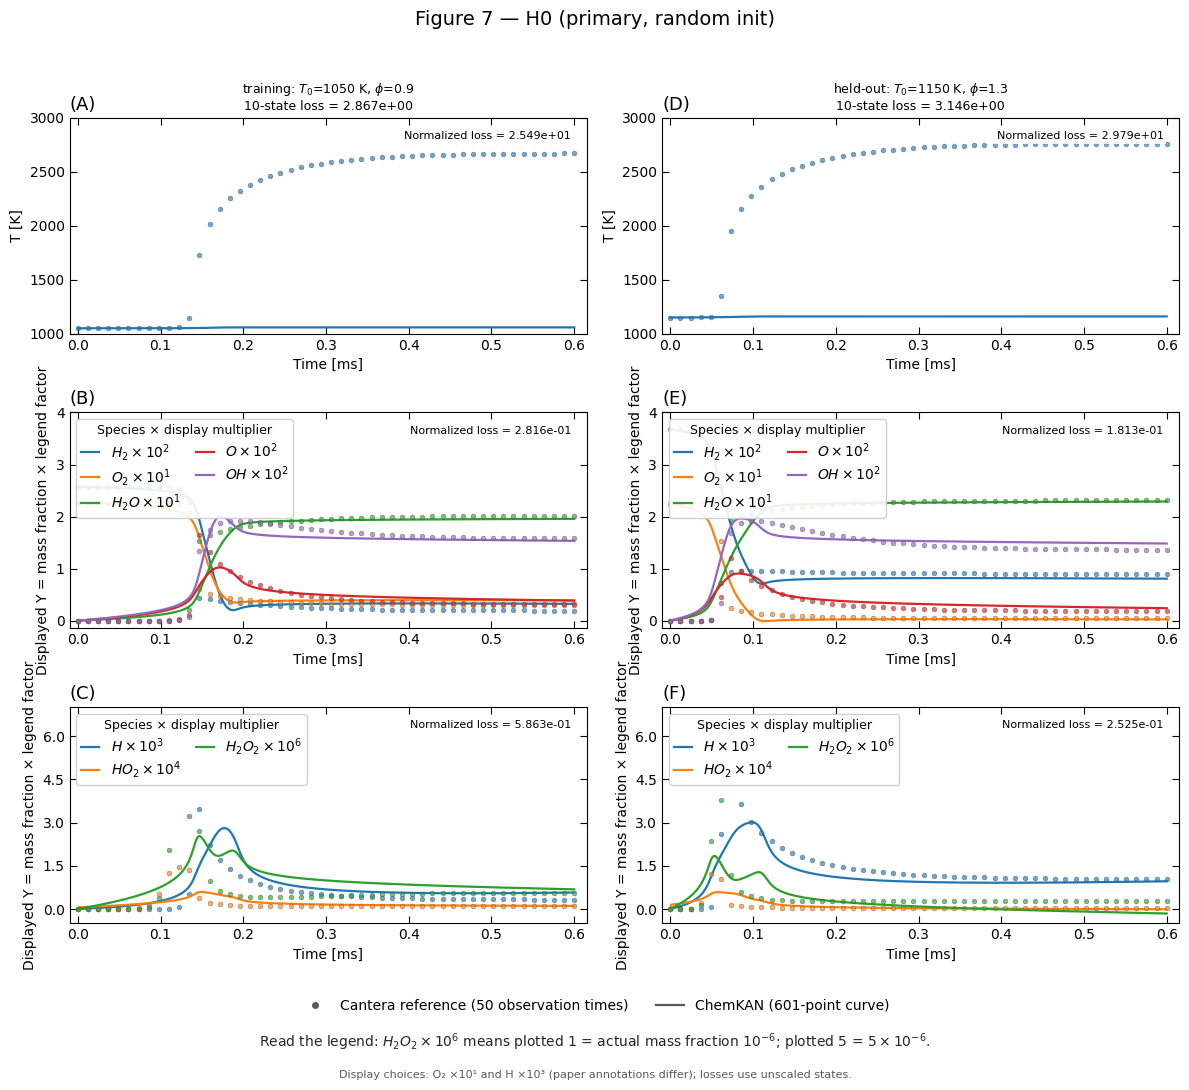

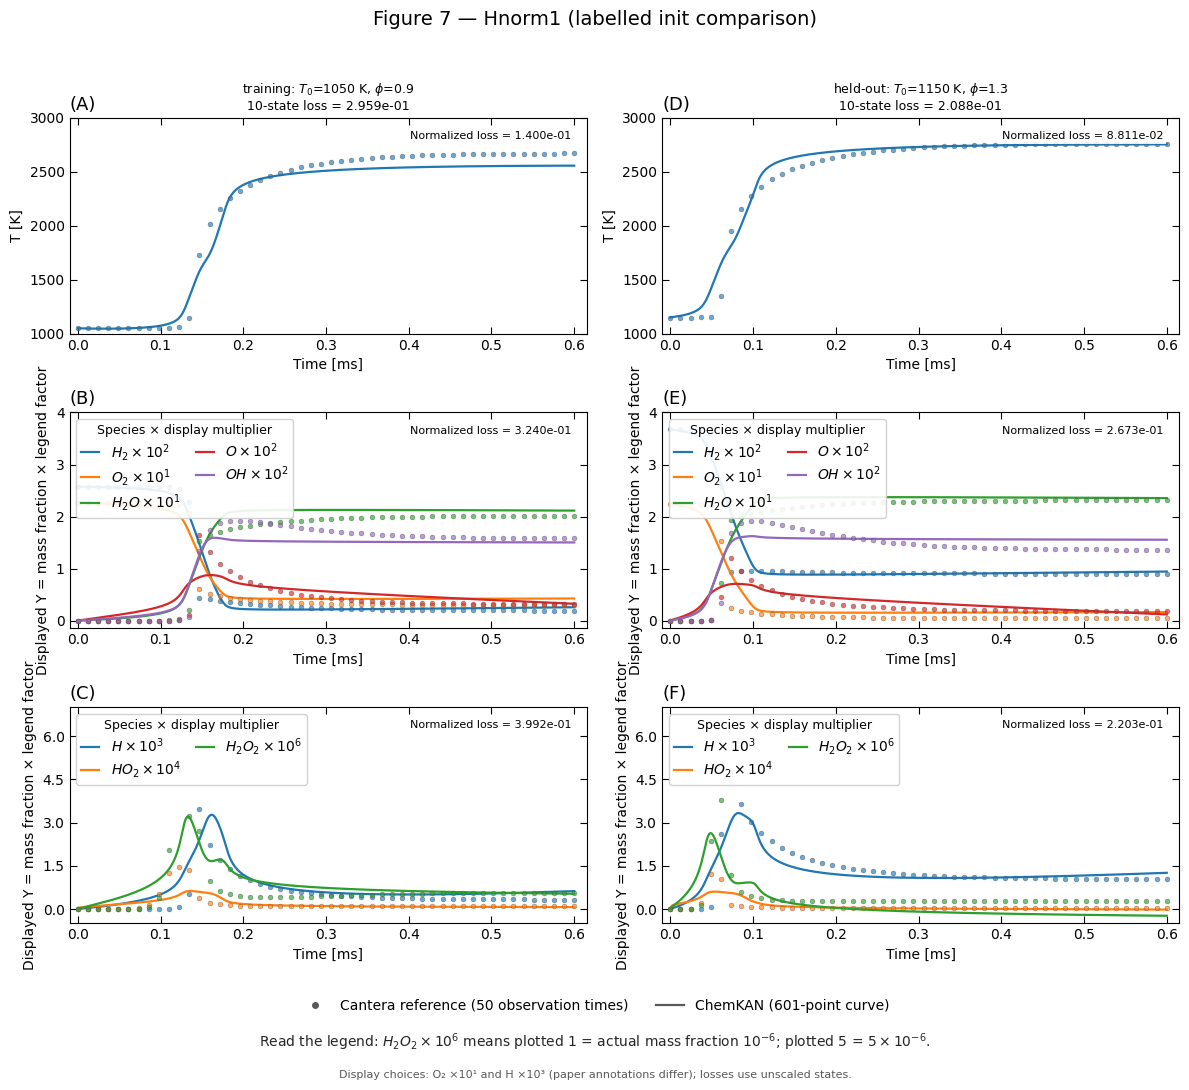

,model,condition,role,case_Eq18_MSE,T_MSE,H2_MSE,H_MSE,O_MSE,O2_MSE,OH_MSE,H2O_MSE,HO2_MSE,H2O2_MSE,N2_MSE
0,"H0 (primary, random init)",1050/0.9,training,2.866599,25.494375,0.188361,0.192140,0.428566,0.283107,0.232325,0.275718,1.298385,0.268312,0.004704
1,"H0 (primary, random init)",1150/1.3,held-out,3.146122,29.787168,0.088151,0.215534,0.171768,0.114488,0.375356,0.156804,0.446988,0.095008,0.009954
2,Hnorm1 (labelled init comparison),1050/0.9,training,0.295947,0.140029,0.088256,0.158124,0.592539,0.215837,0.450126,0.273347,0.918562,0.120945,0.001703
3,Hnorm1 (labelled init comparison),1150/1.3,held-out,0.208795,0.088106,0.108828,0.157577,0.275742,0.253675,0.501105,0.197263,0.390291,0.112952,0.002408


Shared Figure-7 limits (temperature, major species, minor species): [(1000.0, 3000.0), (-0.14818184839095921, 4.0), (-0.4882249376922846, 7.0)]


In [4]:
# Figure code: chemkan/scripts/figures/fig07_hydrogen_trajectories.py
import pandas as pd

from fig07_hydrogen_trajectories import CONDITIONS
from fig07_hydrogen_trajectories import make_figure as make_fig07

# Re-exported for the diagnostic cells further down, so the conditions and the dense grid
# have one definition (the figure script's).
CONDS = CONDITIONS

_, fig07_results = make_fig07(
    run_dirs={label: directory for label, (_stem, directory) in SETS.items()},
    output_dir=FIG_DIR, table_path=TABLE_DIR / "fig07_hydrogen_per_state_mse.csv",
    show=True)
t_d = fig07_results["t_dense"]

display(pd.DataFrame(fig07_results["rows"]).drop(columns="checkpoint"))
print("Shared Figure-7 limits (temperature, major species, minor species):",
      fig07_results["row_limits"])

### Figure 7 companion — true mass fractions, no display multipliers

The figure above is the **paper-comparable** view: it uses per-species display multipliers
so all nine species share a panel, exactly as the paper presents them. Those multipliers
cost interpretability — each curve in a panel carries its own unit, so relative magnitudes
between curves cannot be read off the axis, and a single secondary y-axis cannot undo it
because the multipliers differ *within* a panel (row B mixes \u00d710\u00b2 and \u00d710\u00b9; row C mixes
\u00d710\u00b3, \u00d710\u2074 and \u00d710\u2076).

This companion therefore plots the **same predictions and the same reference** at true mass
fraction, with no multiplier anywhere. Only the display changes: no data, prediction, loss
or checkpoint differs between the two views.

The species rows use a **symlog** y axis, linear within \u00b110\u207b\u2076 and logarithmic outside it.
Symlog rather than log because several predicted mass fractions go **negative** at the
held-out condition, and a log axis would silently drop exactly those points instead of
showing an unphysical prediction. The linear band is shaded so the two regimes are not
confused. Temperature stays linear in kelvin, unchanged from the view above.


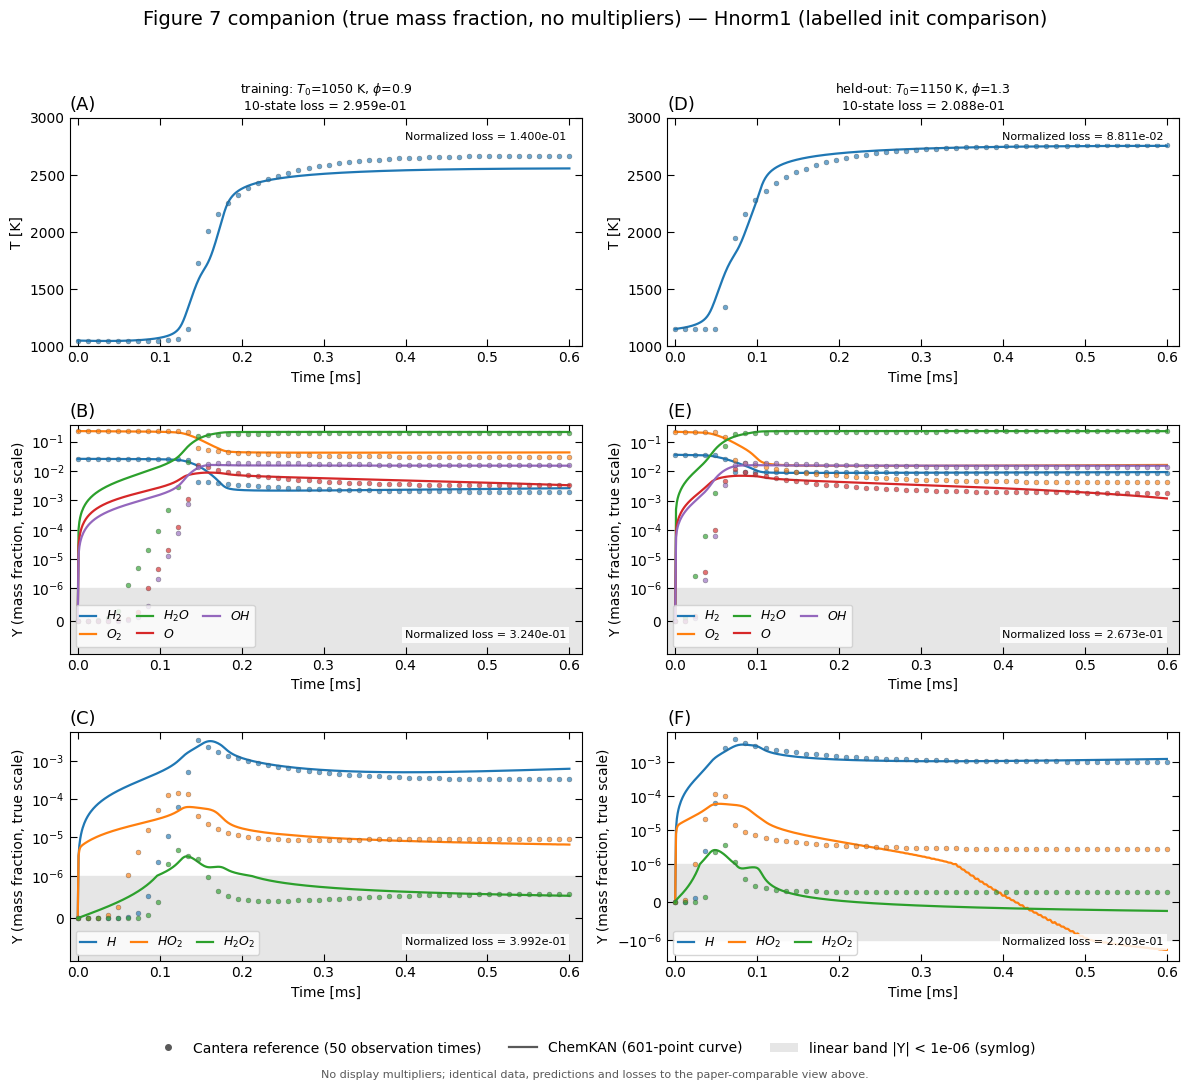

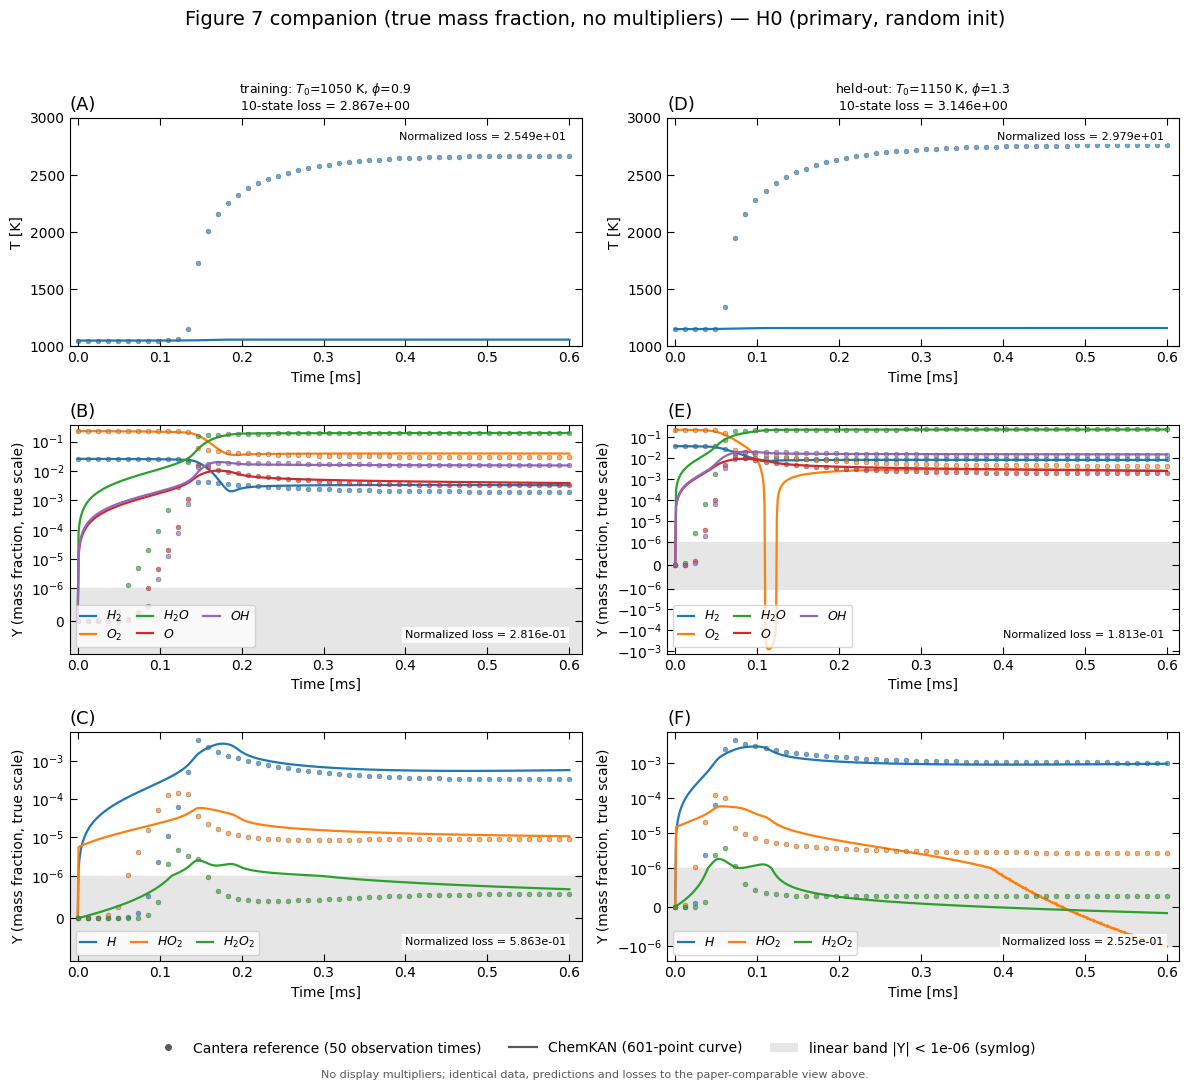

Predicted mass fractions that go negative (visible only on the symlog companion):
  H0 (primary, random init)              T0=1150 K phi=1.3: O2, HO2, H2O2
  Hnorm1 (labelled init comparison)      T0=1150 K phi=1.3: HO2, H2O2


In [5]:
# Figure code: chemkan/scripts/figures/fig07_hydrogen_trajectories.py
# Reuses the evaluation above (precomputed=...) rather than integrating again.
from fig07_hydrogen_trajectories import make_true_scale_figure

_, companion = make_true_scale_figure(precomputed=fig07_results, output_dir=FIG_DIR,
                                      show=True)

print("Predicted mass fractions that go negative (visible only on the symlog companion):")
for (label, T0, phi), bad in sorted(companion["negatives"].items()):
    print(f"  {label:38s} T0={T0:.0f} K phi={phi}: {', '.join(bad)}")
if not companion["negatives"]:
    print("  none")

### Figure 8A — paper-scale view and full-range comparison

The first pair of heatmaps uses **0–10 ×10⁻⁴**, matching the paper's displayed numerical
range. Colours are reversed as requested: **smaller MSE is darker**. Navy crosses mark
35 training conditions and a teal dot marks the held-out case; 405 additional grid
points are unseen. Both models share the same normalization, limits and colours.

The upper colour-bar extension means **greater than 10⁻³**, not equal to 10⁻³.
Every saved error is above this bound for both runs, so the first view saturates at the
light end. The second pair uses the full measured range, with the same dark-for-small
convention, to reveal the spatial differences. The table gives actual minima, medians,
maxima and overflow counts. No error values are changed or divided to fit the paper.

Our loss is the normalized trajectory MSE summed over observation times (Eq. 18).
The paper's precise time-reduction convention remains unresolved; absolute magnitudes
must be compared with that caveat. The 21×21 grid is reconstructed from its count and
spacing; normalization always uses the original training statistics.

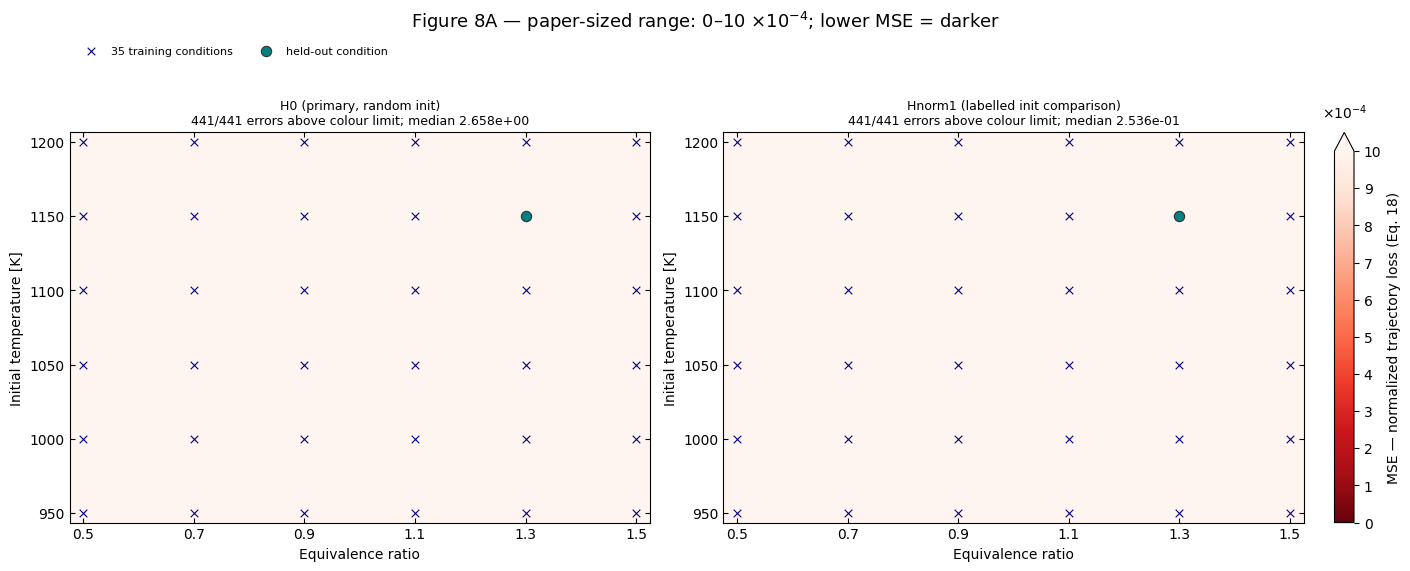

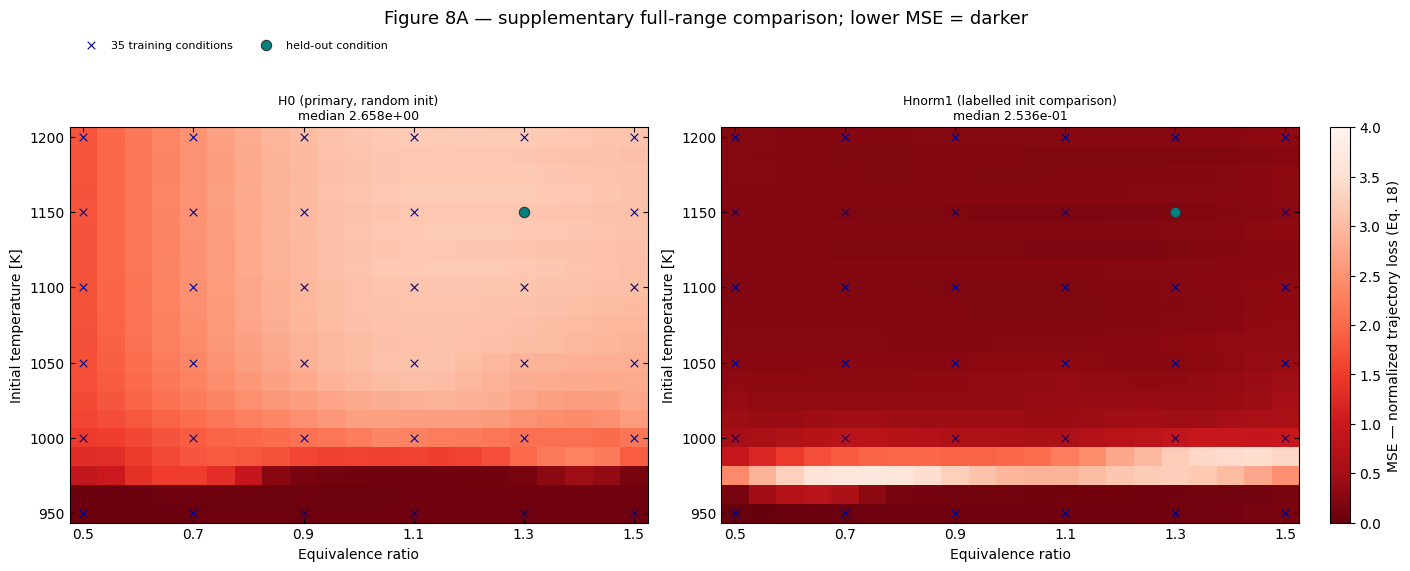

,model,minimum,median,maximum,above_paper_scale,evaluated,paper_scale_max
0,"H0 (primary, random init)",0.031972,2.657622,3.222625,441,441,0.001
1,Hnorm1 (labelled init comparison),0.012698,0.253554,3.691566,441,441,0.001


In [6]:
# Figure code: chemkan/scripts/figures/fig08_hydrogen_generalization.py
import pandas as pd

from fig08_hydrogen_generalization import make_figure as make_fig08a

_, fig08a_results = make_fig08a(
    table_paths={label: GEN / f"{stem}_generalization_441.csv"
                 for label, (stem, _d) in SETS.items()},
    output_dir=FIG_DIR, show=True)

display(pd.DataFrame(fig08a_results["scale_rows"]))

### Figure 8A in the time-averaged reduction

The colour scale above is the paper's, 0–10 × 10⁻⁴, and our summed Eq. 18 losses sit far
above it. Dividing by `N_t = 50` puts them on the reduction the paper's axis appears to
use, which is the fairer visual comparison — though, as the numbers below show, it does
not close the gap.

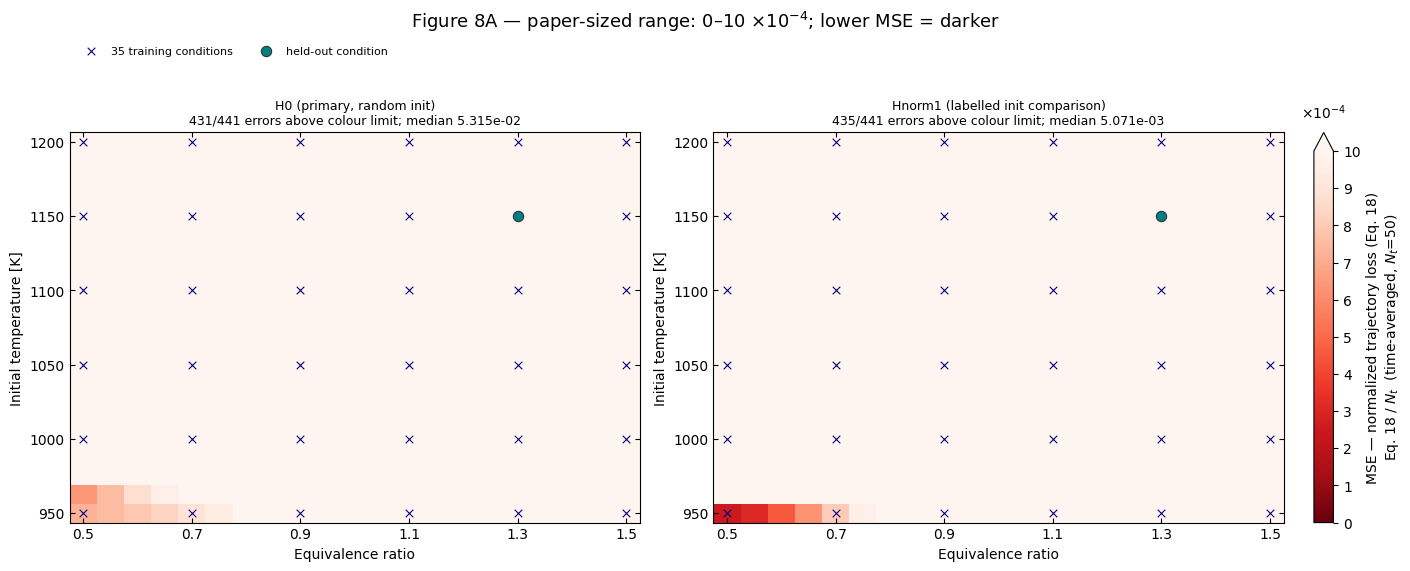

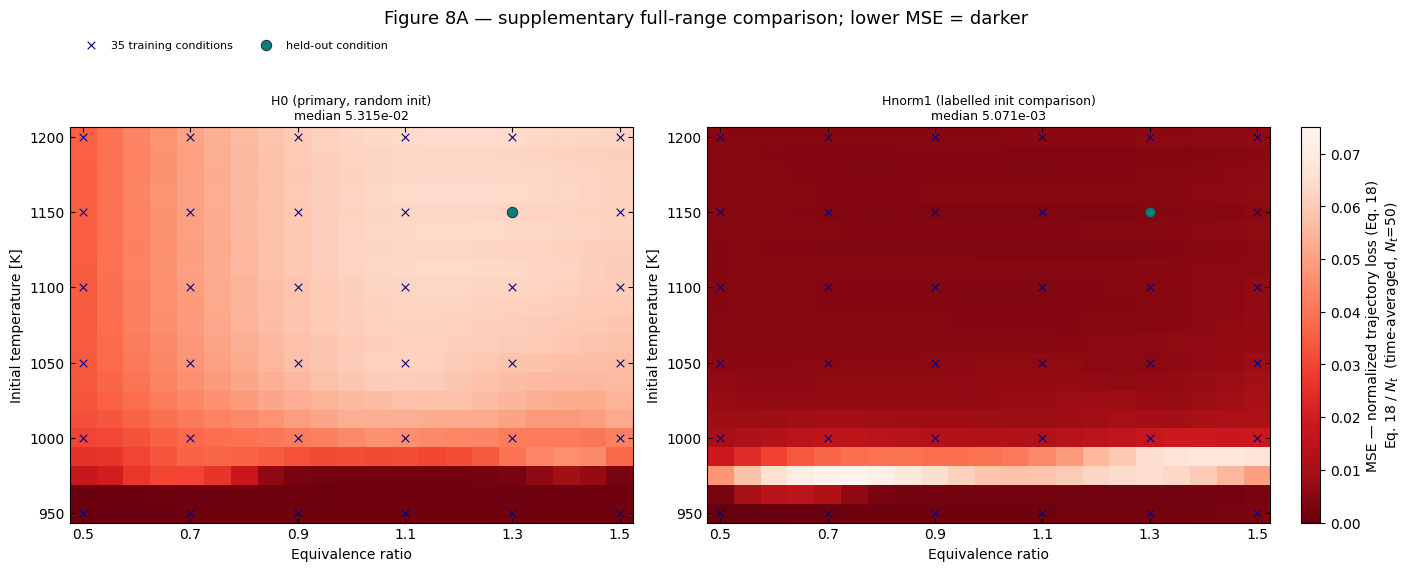

reduction: Eq. 18 / $N_t$  (time-averaged, $N_t$=50)
  H0 (primary, random init)            median 5.315e-02 (time-averaged) vs the paper's colour ceiling 1e-03
  Hnorm1 (labelled init comparison)    median 5.071e-03 (time-averaged) vs the paper's colour ceiling 1e-03


In [7]:
from fig08_hydrogen_generalization import make_figure as make_fig08a

_, fig08a_time_averaged = make_fig08a(
    table_paths={label: GEN / f"{stem}_generalization_441.csv"
                 for label, (stem, _d) in SETS.items()},
    output_dir=FIG_DIR, time_averaged=True, show=True)

n_times = 50
print("reduction:", fig08a_time_averaged["reduction"])
for row in fig08a_time_averaged["scale_rows"]:
    print(f"  {row['model']:36} median {row['median'] / n_times:.3e} (time-averaged) "
          f"vs the paper's colour ceiling {row['paper_scale_max']:.0e}")

### Figure 8B — ignition delay

Ignition delay = time of maximum dT/dt. Reference and model are put on the **same** dense
601-point grid over 0–0.6 ms and through the **same** estimator, so a coarse 50-point
reference derivative is never compared against a dense model derivative. The evaluated set
is fixed by which *reference* trajectories ignite — 30 of 36; the six 950 K cases do not
ignite in the window — never by whether the model succeeds.

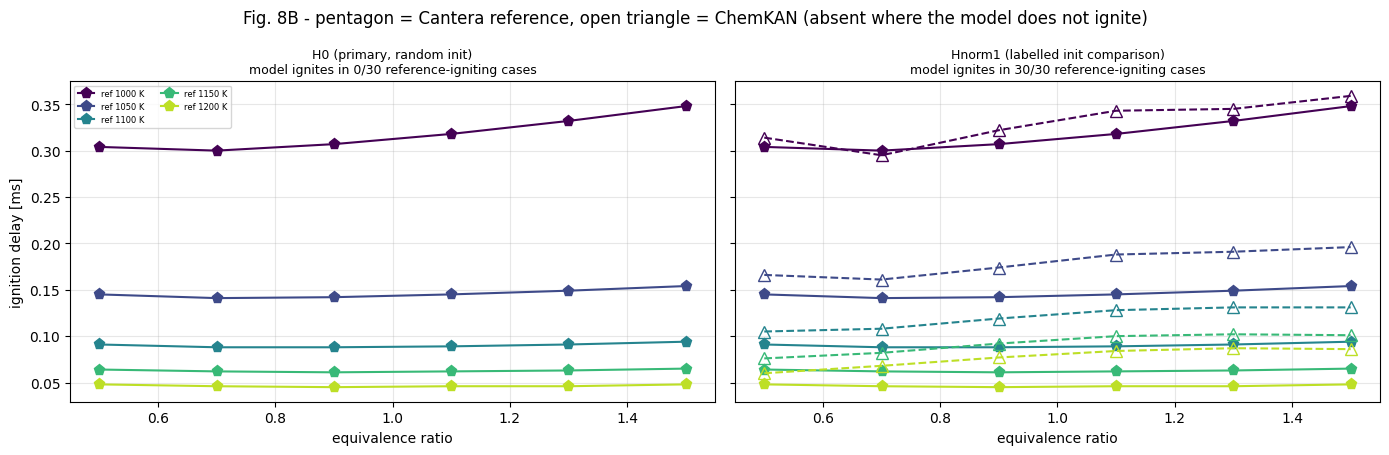

H0 (primary, random init): 30 reference-igniting conditions | statuses {'no_ignition_in_window': 30}
Hnorm1 (labelled init comparison): 30 reference-igniting conditions | statuses {'ignited': 30}
    |relative delay error|: median 28.9%  max 89.1%


In [8]:
# Figure code: chemkan/scripts/figures/fig08_hydrogen_ignition.py
from fig08_hydrogen_ignition import make_figure as make_fig08b

_, fig08b_results = make_fig08b(
    table_paths={label: TABLE_DIR / f"hydrogen_ignition_delay_{stem}.csv"
                 for label, (stem, _d) in SETS.items()},
    output_path=FIG_DIR / "fig08b_hydrogen_ignition_delay", show=True)

for label, summary in fig08b_results.items():
    print(f"{label}: {summary['conditions']} reference-igniting conditions | "
          f"statuses {summary['statuses']}")
    if summary["median_relative_error"] is not None:
        print(f"    |relative delay error|: median {summary['median_relative_error']:.1%}  "
              f"max {summary['max_relative_error']:.1%}")

### Table I — networks, parameters, species, and a *local* efficiency measurement

The paper's ChemNODE and ChemKAN speed-ups are literature values measured against
Arrhenius.jl on other hardware with an unstated timing scope. Our number is a **local
PyTorch-vs-Cantera benchmark** over the same task (36 initial conditions, 50 output times,
0–0.6 ms). The two are reported side by side and must not be merged.

Accuracy is reported *with* the timing, because a model that does not reproduce the
dynamics is fast for the wrong reason.

In [9]:
bench = {}
for label, (stem, d) in SETS.items():
    bench[label] = _json.loads(
        (TABLE_DIR / f"hydrogen_inference_benchmark_{stem}.json").read_text())

table = [
    dict(model="ChemNODE (Ref. 17)", networks=7, parameters=637,
         species="H2,O2,H2O,N2,O,OH + T", speedup="2.3x", source="paper_reported"),
    dict(model="ChemKAN (paper)", networks=1, parameters=344,
         species="9 species + T", speedup="2.0x", source="paper_reported"),
]
for label, b in bench.items():
    ok = next(r for r in b["cantera"]["runs"] if r.get("status") == "ok")
    acc = b["accuracy"]
    table.append(dict(
        model=f"ChemKAN ({label})", networks=1, parameters=b["parameter_count"],
        species=f"{len(species)} species + T",
        speedup=f"{ok['speedup_vs_chemkan']:.2f}x", source="local_measured"))
    print(f"{label}")
    print(f"   ChemKAN {b['chemkan']['median_s']:.3f} s vs Cantera {ok['median_s']:.3f} s "
          f"(rtol={ok['rtol']:g}, atol={ok['atol']:g})  ->  {ok['speedup_vs_chemkan']:.2f}x")
    print(f"   ignites in {acc['chemkan_igniting_within_reference_set']}/"
          f"{acc['reference_igniting_conditions']} reference-igniting conditions "
          f"(+{acc['chemkan_igniting_where_reference_does_not']} where the reference does not); "
          f"median peak-T error {acc['peak_temperature_abs_error_K']['median']:.1f} K")
    for r in b["cantera"]["runs"]:
        if r.get("status") != "ok":
            print(f"   Cantera at rtol={r['rtol']:g} atol={r['atol']:g}: {r['status']}")
    print(f"   hardware: {b['hardware']['machine']}, torch {b['chemkan']['torch']}, "
          f"{b['chemkan']['threads']} threads, {b['warmup']} warm-up + {b['repetitions']} reps")

if SAVE_TABLES:
    f = TABLE_DIR / "hydrogen_efficiency.csv"
    with f.open("w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(table[0])); w.writeheader(); w.writerows(table)
    print("\nsaved", f)

H0 (primary, random init)
   ChemKAN 1.871 s vs Cantera 0.271 s (rtol=1e-09, atol=1e-15)  ->  0.14x
   ignites in 0/30 reference-igniting conditions (+0 where the reference does not); median peak-T error 1546.5 K
   Cantera at rtol=1e-06 atol=1e-08: integration_failed: CanteraError
   hardware: arm64, torch 2.13.0, 4 threads, 2 warm-up + 5 reps
Hnorm1 (labelled init comparison)
   ChemKAN 0.470 s vs Cantera 0.236 s (rtol=1e-09, atol=1e-15)  ->  0.50x
   ignites in 30/30 reference-igniting conditions (+2 where the reference does not); median peak-T error 38.1 K
   Cantera at rtol=1e-06 atol=1e-08: integration_failed: CanteraError
   hardware: arm64, torch 2.13.0, 4 threads, 2 warm-up + 5 reps

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_efficiency.csv


**Table I outcome.** Both local measurements are **slower** than Cantera (0.14× for
`H0`, 0.50× for `Hnorm1`), not the paper's 2.0× speed-up. The comparison is not
like-for-like — different reference implementation, hardware and timing scope — so this
neither confirms nor refutes the paper's number; it is our own measurement, reported as
such. Cantera could not integrate at the model's own tolerances (rtol 1e-6, atol 1e-8) and
that is recorded per tolerance setting rather than hidden.

Note also that `H0` is *slower* than `Hnorm1` despite never igniting: a badly conditioned
right-hand side can force small solver steps without producing any physical ignition.

---

## Section III B — status against the paper

| paper result | our result | status | remaining difference |
|---|---|---|---|
| Fig. 7 temperature + species at both published conditions | `H0` produces no ignition at either condition; `Hnorm1` reproduces the rise | **not matched** (`H0`) | the primary run's Stage-2 solution is non-igniting |
| Fig. 8A 441-condition errors | all 441 evaluated per condition, 0 integration failures | **evaluated, not matched** | `H0` median MSE 2.66; `Hnorm1` 0.254 |
| Fig. 8A ≈10⁻⁴ at the 1000 K training conditions | our per-condition MSEs are order 10⁻¹–10⁰ | **not matched** | same absolute-error gap as biodiesel |
| Fig. 8B ignition delay over 30 conditions | `H0` ignites in **0/30**; `Hnorm1` in **30/30**, median delay error 28.9 % | **not matched** (`H0`), **partially matched** (`Hnorm1`) | `Hnorm1` also ignites in 2 conditions where the reference does not |
| Table I: 1 network, 344 parameters, 9 species + T | 1 network, 344 measured, 9 species + T | **matched** | — |
| Table I: 2.0× speed-up | 0.14× (`H0`), 0.50× (`Hnorm1`), local PyTorch-vs-Cantera | **not matched** | different reference implementation, hardware and timing scope |

**What this establishes.** The N=4/base-ON reading does not remove the Stage-2 ignition
failure. A single norm-matched initialization (`Hnorm1`) does recover ignition across all
30 reference-igniting conditions, which sharpens the evidence that the thermodynamic
pathway's initialization is strongly implicated — but it is **one** initialization, not a
seed study, and it does not establish a root cause. The detailed failure and initialization
diagnostics remain in Notebook 09; this notebook does not duplicate them.

## Base-OFF versus base-ON — saved initialization comparisons

Compare the historical **N=5/base-OFF** architecture against **N=4/base-ON**, at the
same 344-parameter count, separately for default random and norm-matched direction-1
thermodynamic initialization. Both use direct autograd and 10,000 Stage-2 epochs.
These are separately trained architectures with their own Stage-1 checkpoints;
this is **not** a base-activation toggle on identical learned weights, nor an FSA comparison.
The norm-matched pair uses identical recorded initial thermodynamic Linear vectors.

The curves show temperature at the two Figure-7 conditions. The tables include full
train/test losses and condition-specific total, temperature and species losses. All losses
use the existing train-only normalization and sum over the 50 observation times;
curves use 601 display times. No training occurs. The historical default-random row is
the control specified for the first proposed FSA experiment.


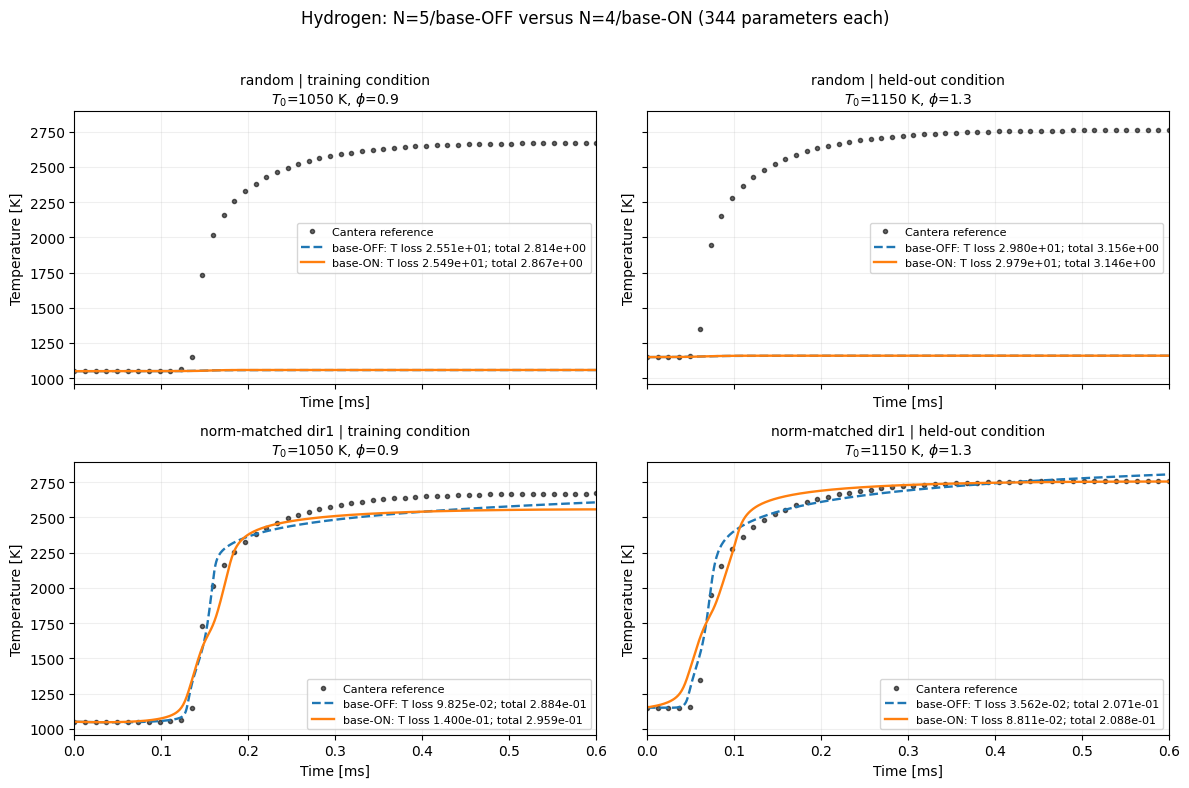

,initialization,architecture,num_basis,parameters,train_MSE,held_out_MSE
0,random,base-OFF,5,344,2.122741,3.155575
1,random,base-ON,4,344,2.139383,3.146122
2,norm-matched dir1,base-OFF,5,344,0.269726,0.207083
3,norm-matched dir1,base-ON,4,344,0.310101,0.208795


,initialization,architecture,condition,role,trajectory_MSE,temperature_MSE,species_mean_MSE,peak_temperature_K
0,random,base-OFF,1050 K / phi=0.9,training condition,2.814424,25.510193,0.292672,1058.007690
1,random,base-OFF,1150 K / phi=1.3,held-out condition,3.155575,29.800449,0.195034,1159.597900
2,random,base-ON,1050 K / phi=0.9,training condition,2.866599,25.494375,0.352402,1058.504761
3,random,base-ON,1150 K / phi=1.3,held-out condition,3.146122,29.787168,0.186006,1159.913330
4,norm-matched dir1,base-OFF,1050 K / phi=0.9,training condition,0.288421,0.098253,0.309551,2606.853027
5,norm-matched dir1,base-OFF,1150 K / phi=1.3,held-out condition,0.207083,0.035625,0.226134,2804.952148
6,norm-matched dir1,base-ON,1050 K / phi=0.9,training condition,0.295947,0.140029,0.313271,2556.883545
7,norm-matched dir1,base-ON,1150 K / phi=1.3,held-out condition,0.208795,0.088106,0.222205,2754.465088


Verified four saved runs and identical norm-matched initial Linear vectors. Source paths are in hydrogen_base_off_vs_on_runs.csv.


In [11]:
import json
import pandas as pd

base_compare_root = ROOT / "results/reproduction/chemkan/hydrogen/diagnostics"
base_compare_runs = [
    ("random", "base-OFF", "thermo_init_random_stage2_10000_seed0"),
    ("random", "base-ON", "base_on_n4/random_stage2_10000_seed0"),
    ("norm-matched dir1", "base-OFF", "thermo_init_scaled_random_normmatched_dir1_stage2_10000"),
    ("norm-matched dir1", "base-ON", "base_on_n4/normmatched_dir1_stage2_10000"),
]
base_compare_conditions = [(1050., .9, "training condition"), (1150., 1.3, "held-out condition")]
base_compare_times = np.linspace(float(t[0]), float(t[-1]), 601)
base_compare_summary, base_compare_losses, base_compare_init = [], [], []
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for init, architecture, relative in base_compare_runs:
    directory = base_compare_root / relative
    config = json.loads((directory / "config.json").read_text())
    metrics = json.loads((directory / "metrics.json").read_text())
    checkpoint = torch.load(directory / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    comparison_model = build_chemkan(checkpoint, len(species), "cpu")
    comparison_solver = solver_from_ckpt(checkpoint)
    comparison_norm = load_input_scaling(checkpoint, "cpu")
    assert config["parameter_count"] == sum(p.numel() for p in comparison_model.parameters()) == 344
    assert config["architecture"]["num_basis"] == (5 if architecture == "base-OFF" else 4)
    assert config["architecture"]["use_base_act"] == (architecture == "base-ON")
    assert config["epochs"]["stage2"] == 10000 and config["sensitivity_backend"] == "direct_autograd"
    if init == "norm-matched dir1":
        base_compare_init.append(config["thermo_init"]["resulting_vector"])
    base_compare_summary.append(dict(initialization=init, architecture=architecture,
        num_basis=config["architecture"]["num_basis"], parameters=344,
        train_MSE=metrics["train_mse"], held_out_MSE=metrics["test_mse"],
        run=str(directory.relative_to(ROOT)), stage1_source=config["stage1_from"]["run_id"]))
    row = 0 if init == "random" else 1
    for col, (T0, phi, role) in enumerate(base_compare_conditions):
        indices = np.flatnonzero(np.isclose(ics[:, 0], T0) & np.isclose(ics[:, 1], phi))
        assert len(indices) == 1
        reference = states[int(indices[0])]
        initial = torch.as_tensor(reference[0], dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            curve = integrate_hydrogen(comparison_model, comparison_norm, comparison_solver,
                                       initial, base_compare_times)[:, 0].numpy()
            observations = integrate_hydrogen(comparison_model, comparison_norm, comparison_solver,
                                              initial, t)[:, 0]
            errors = (full_norm.normalize(observations) - full_norm.normalize(
                torch.as_tensor(reference, dtype=torch.float32))).square().sum(0).numpy()
        assert np.isfinite(curve).all() and np.isfinite(errors).all()
        if col == 1:
            assert np.isclose(errors.mean(), metrics["test_mse"], rtol=1e-4, atol=1e-6)
        base_compare_losses.append(dict(initialization=init, architecture=architecture,
            condition=f"{T0:g} K / phi={phi:g}", role=role,
            trajectory_MSE=float(errors.mean()), temperature_MSE=float(errors[-1]),
            species_mean_MSE=float(errors[:-1].mean()), peak_temperature_K=float(curve[:, -1].max()),
            temperature_rise_K=float(curve[:, -1].max()-curve[0, -1]),
            **{f"{sp}_MSE": float(errors[k]) for k, sp in enumerate(species)}))
        ax = axes[row, col]
        if architecture == "base-OFF":
            ax.plot(t * 1e3, reference[:, -1], "ko", ms=3, alpha=.6, label="Cantera reference")
        ax.plot(base_compare_times * 1e3, curve[:, -1],
                color="tab:blue" if architecture == "base-OFF" else "tab:orange",
                ls="--" if architecture == "base-OFF" else "-", lw=1.7,
                label=f"{architecture}: T loss {errors[-1]:.3e}; total {errors.mean():.3e}")
        ax.set_title(f"{init} | {role}\n$T_0$={T0:g} K, $\phi$={phi:g}", fontsize=10)
        ax.set_xlabel("Time [ms]"); ax.set_ylabel("Temperature [K]")
        ax.set_xticks(np.arange(0, .61, .1)); ax.set_xlim(0, .6)
        ax.legend(fontsize=8); ax.grid(alpha=.2)
assert base_compare_init[0] == base_compare_init[1]
fig.suptitle("Hydrogen: N=5/base-OFF versus N=4/base-ON (344 parameters each)")
fig.tight_layout(rect=(0, 0, 1, .96))
if SAVE_FIGURES:
    for extension in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"hydrogen_base_off_vs_on_comparison.{extension}", dpi=180, bbox_inches="tight")
plt.show()
base_comparison_summary = pd.DataFrame(base_compare_summary)
base_comparison_metrics = pd.DataFrame(base_compare_losses)
display(base_comparison_summary.drop(columns=["run", "stage1_source"]))
display(base_comparison_metrics.iloc[:, :8])
if SAVE_TABLES:
    base_comparison_summary.to_csv(TABLE_DIR / "hydrogen_base_off_vs_on_runs.csv", index=False)
    base_comparison_metrics.to_csv(TABLE_DIR / "hydrogen_base_off_vs_on_metrics.csv", index=False)
print("Verified four saved runs and identical norm-matched initial Linear vectors. Source paths are in hydrogen_base_off_vs_on_runs.csv.")


---
## Appendix — H0 failure diagnostics

The paper comparisons above are the main figures. The sections below retain the
primary H0 ignition check and failure analyses for context; they do not add another
Figure 7 or replace the Hnorm1 comparison. Further initialization studies are in Notebook 09.


## Ignition gate

Before any Section III B figure: does the model, integrated from the initial condition
alone, actually ignite? A parameter-count assertion passes on a model that flatlines.

The tolerances below are a **reproduction choice**, not paper-stated.

In [12]:
PEAK_TOL_K, DELAY_TOL_REL = 150.0, 0.25

def integrate_case(T0, phi, t_eval=None):
    i = int(np.argmin(np.abs(ics[:, 0] - T0) + np.abs(ics[:, 1] - phi)))
    tt = t if t_eval is None else t_eval
    u0 = torch.as_tensor(states[i, 0], dtype=torch.get_default_dtype()).unsqueeze(0)
    pred = integrate_hydrogen(model, input_norm, solver, u0, tt)
    return i, states[i], pred[:, 0].numpy(), tt

def ignition_delay(tt, T, rise=100.0):
    T = np.asarray(T, float)
    if T.max() - T[0] < rise:
        return None
    return float(np.asarray(tt)[int(np.argmax(np.gradient(T, np.asarray(tt))))])

gate_rows, gate_pass = [], True
for T0, phi, role in [(1050, 0.9, "training"), (1150, 1.3, "held-out")]:
    _, ref, pred, tt = integrate_case(T0, phi)
    Tp, Tr = pred[:, -1], ref[:, -1]
    dp, dr = ignition_delay(tt, Tp), ignition_delay(tt, Tr)
    peak_err = abs(Tp.max() - Tr.max())
    ok = peak_err <= PEAK_TOL_K and (
        dr is None or (dp is not None and abs(dp - dr) / dr <= DELAY_TOL_REL))
    gate_pass &= ok
    gate_rows.append(dict(T0=T0, phi=phi, role=role,
                          peak_pred_K=float(Tp.max()), peak_ref_K=float(Tr.max()),
                          peak_err_K=float(peak_err),
                          delay_pred_s=dp, delay_ref_s=dr, passed=bool(ok)))
    print(f"T0={T0} phi={phi} [{role:8s}] peak {Tp.max():7.1f} K vs {Tr.max():7.1f} K"
          f"   ignites: {'yes' if dp else 'NO':3s}   {'PASS' if ok else 'FAIL'}")

IGNITION_GATE = "PASSED" if gate_pass else "FAILED"
print("\nIGNITION GATE:", IGNITION_GATE)

T0=1050 phi=0.9 [training] peak  1058.5 K vs  2669.7 K   ignites: NO    FAIL


T0=1150 phi=1.3 [held-out] peak  1159.9 K vs  2761.6 K   ignites: NO    FAIL

IGNITION GATE: FAILED


### Gate outcome

If **FAILED**, the checkpoint does not reproduce autoignition. The figures below are then
plotted as diagnostic evidence of that failure, not as reproductions of the paper's
results, and headings are marked accordingly.

Stage-1 and Stage-2 losses are shown for context. Stage 1 optimises the kinetic core with
the observed temperature **supplied**, so a low Stage-1 loss does not imply the model can
initiate ignition on its own.

In [13]:
for stage in (1, 2):
    # Stage 1 was trained once and shared: H0 branches from it and stores only Stage 2.
    f = (STAGE1_DIR if stage == 1 else RUN_DIR) / f"history_stage{stage}.csv"
    if not f.exists():
        print(f"stage {stage}: no history file")
        continue
    rows = list(csv.DictReader(f.open()))
    key = next((k for k in rows[0] if "total" in k.lower() and "loss" in k.lower()),
               next(k for k in rows[0] if "loss" in k.lower()))
    print(f"stage {stage}: {len(rows)} epochs | first {float(rows[0][key]):.4e}"
          f" | final {float(rows[-1][key]):.4e}   (column '{key}')")

stage 1: 10000 epochs | first 8.3228e+00 | final 3.1488e-01   (column 'total_loss')
stage 2: 10000 epochs | first 3.3243e+00 | final 2.1431e+00   (column 'total_loss')


### Fig. 8A computed as a diagnostic map

The map is computed even though the gate failed. A non-igniting model is not uniformly
bad: the reference itself does not ignite at the coldest conditions within 0.6 ms, so the
model should reproduce *those* well. The 21x21 map therefore shows exactly **where** the
model works and where it breaks, which is more informative than skipping it.

This is **not** a reproduction of the paper's Fig. 8A - the paper's map spans roughly
0 to 1e-3 across a model that ignites everywhere. It is a diagnostic of the failure.

integrating 441 conditions ...


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/fig08a_hydrogen_DIAGNOSTIC_map.png


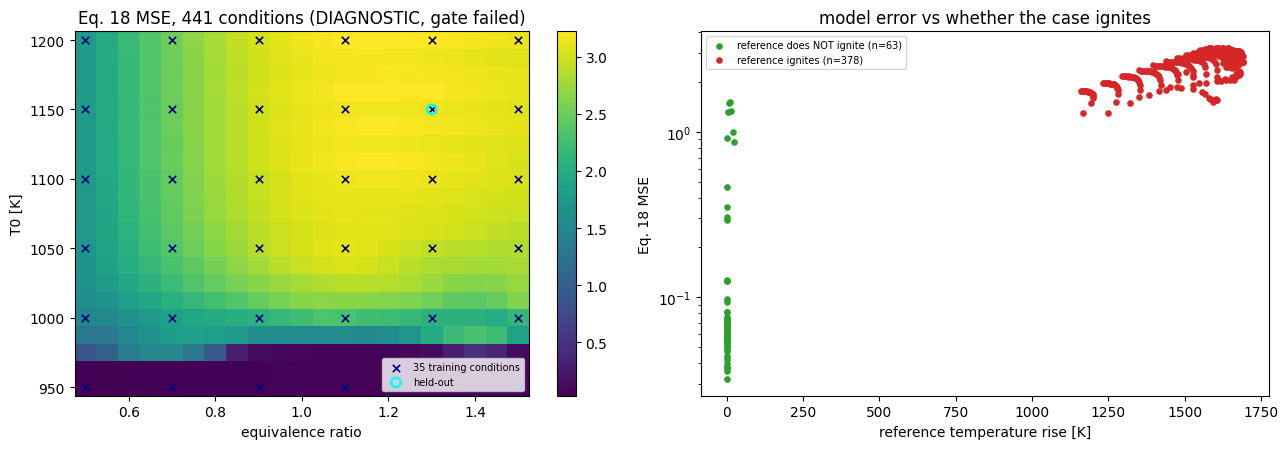


non-igniting cases (n= 63): median MSE 0.0686
igniting cases     (n=378): median MSE 2.8402
ratio: 41.4x


In [14]:
fine = np.load(ROOT / "chemkan/data/generated/hydrogen_fine.npz", allow_pickle=True)
fT, fS = fine["t"], fine["states"]                      # (441, Nt, 10)
fics = fine["ics"]
print("integrating 441 conditions ...")

u0 = torch.as_tensor(fS[:, 0], dtype=torch.get_default_dtype())
predf = integrate_hydrogen(model, input_norm, solver, u0,
                           torch.as_tensor(fT, dtype=torch.get_default_dtype()))
predf = predf.detach()                                   # (Nt, 441, 10)

truthf = torch.as_tensor(fS, dtype=torch.get_default_dtype()).permute(1, 0, 2)
sq = (full_norm.normalize(predf) - full_norm.normalize(truthf)) ** 2
mse441 = sq.mean(-1).sum(0).numpy()                      # Eq. 18 per condition

T0s, phis = np.unique(fics[:, 0]), np.unique(fics[:, 1])
grid = np.full((len(T0s), len(phis)), np.nan)
for k, (T0, phi) in enumerate(fics):
    grid[np.argmin(abs(T0s - T0)), np.argmin(abs(phis - phi))] = mse441[k]

ref_rise = fS[:, :, -1].max(1) - fS[:, :, -1][:, 0]
ignites = ref_rise > 100.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
im = ax[0].pcolormesh(phis, T0s, grid, shading="nearest", cmap="viridis")
ax[0].scatter(ics[:, 1], ics[:, 0], marker="x", s=28, c="navy", lw=1.2,
              label="35 training conditions")
ax[0].scatter([1.3], [1150], marker="o", s=45, facecolor="none", edgecolor="cyan",
              lw=1.8, label="held-out")
ax[0].set_xlabel("equivalence ratio"); ax[0].set_ylabel("T0 [K]")
ax[0].set_title("Eq. 18 MSE, 441 conditions (DIAGNOSTIC, gate failed)")
ax[0].legend(fontsize=7, loc="lower right")
fig.colorbar(im, ax=ax[0])

ax[1].scatter(ref_rise[~ignites], mse441[~ignites], s=14, c="tab:green",
              label=f"reference does NOT ignite (n={(~ignites).sum()})")
ax[1].scatter(ref_rise[ignites], mse441[ignites], s=14, c="tab:red",
              label=f"reference ignites (n={ignites.sum()})")
ax[1].set_xlabel("reference temperature rise [K]"); ax[1].set_ylabel("Eq. 18 MSE")
ax[1].set_yscale("log")
ax[1].set_title("model error vs whether the case ignites")
ax[1].legend(fontsize=7)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig08a_hydrogen_DIAGNOSTIC_map.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "fig08a_hydrogen_DIAGNOSTIC_map.png")
plt.show()

print(f"\nnon-igniting cases (n={(~ignites).sum():3d}): median MSE "
      f"{np.median(mse441[~ignites]):.4f}")
print(f"igniting cases     (n={ignites.sum():3d}): median MSE "
      f"{np.median(mse441[ignites]):.4f}")
print(f"ratio: {np.median(mse441[ignites])/max(np.median(mse441[~ignites]),1e-12):.1f}x")

### Predicted vs reference temperature rise

Instead of ignition delay (undefined for a model that never ignites), this compares the
total temperature rise per condition. It is the single number that separates a model
that ignites from one that does not.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/fig08b_hydrogen_DIAGNOSTIC_rise.png


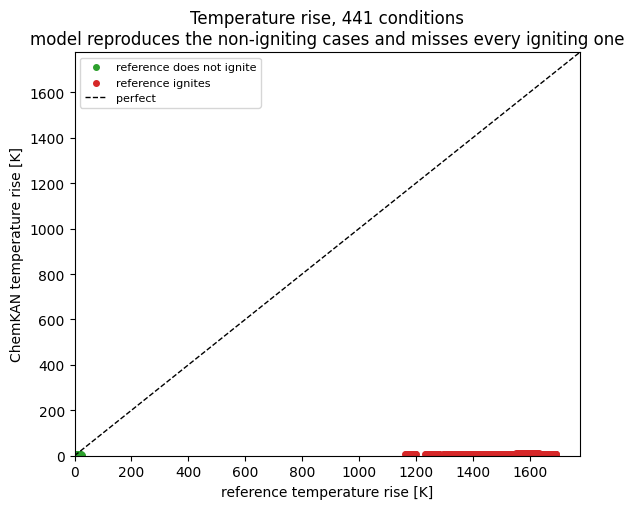

non-igniting: mean |rise error| =     1.5 K
igniting    : mean |rise error| =  1528.2 K


In [15]:
pred_rise = predf[:, :, -1].max(0).values.numpy() - predf[0, :, -1].numpy()

fig, a = plt.subplots(figsize=(6, 5.2))
a.scatter(ref_rise[~ignites], pred_rise[~ignites], s=16, c="tab:green",
          label="reference does not ignite")
a.scatter(ref_rise[ignites], pred_rise[ignites], s=16, c="tab:red",
          label="reference ignites")
lim = [0, ref_rise.max() * 1.05]
a.plot(lim, lim, "k--", lw=1, label="perfect")
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel("reference temperature rise [K]")
a.set_ylabel("ChemKAN temperature rise [K]")
a.set_title("Temperature rise, 441 conditions\n"
            "model reproduces the non-igniting cases and misses every igniting one")
a.legend(fontsize=8)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"fig08b_hydrogen_DIAGNOSTIC_rise.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "fig08b_hydrogen_DIAGNOSTIC_rise.png")
plt.show()

print(f"non-igniting: mean |rise error| = "
      f"{np.abs(pred_rise[~ignites]-ref_rise[~ignites]).mean():7.1f} K")
print(f"igniting    : mean |rise error| = "
      f"{np.abs(pred_rise[ignites]-ref_rise[ignites]).mean():7.1f} K")

In [16]:
# --- Failure-diagnosis setup: open-loop RHS + Stage-1 (observed T) helpers ---
from chemkan.dynamics import ChemKANDynamics, KineticDynamics
from chemkan.temperature import ObservedTemperature
from chemkan.solver import integrate

DIAG_CONDS = [(1050, 0.9, "training"), (1150, 1.3, "held-out")]
m = len(species)
full_dyn = ChemKANDynamics(model, input_normalizer=input_norm)     # physical [Y,T] -> d[Y,T]/dt

def _cond_index(T0, phi):
    return int(np.argmin(np.abs(ics[:, 0] - T0) + np.abs(ics[:, 1] - phi)))

def rhs_along_reference(ref):
    """Model d[Y,T]/dt evaluated on the EXACT reference states (open loop, no integration),
    and the finite-difference reference derivative. Both (Nt, m+1), physical units."""
    tf = torch.as_tensor(t, dtype=torch.float32)
    with torch.no_grad():
        md = torch.stack([full_dyn(tf[j], torch.as_tensor(ref[j], dtype=torch.float32).unsqueeze(0))[0]
                          for j in range(len(t))]).numpy()
    return md, np.gradient(ref, t, axis=0)

def stage1_species_observed_T(ref):
    """Integrate Stage 1 (species only) with THIS condition's true T(t) supplied."""
    obsT = ObservedTemperature(torch.as_tensor(t, dtype=torch.float32),
                               torch.as_tensor(ref[:, -1], dtype=torch.float32).reshape(-1, 1, 1))
    kin = KineticDynamics(model.kinetic, obsT, input_normalizer=input_norm)
    with torch.no_grad():
        return integrate(kin, torch.as_tensor(ref[0, :m], dtype=torch.float32).unsqueeze(0),
                         torch.as_tensor(t, dtype=torch.float32), solver)[:, 0].numpy()

def normstate(arr):
    """Full-state train-only min-max normalization, for comparable per-state errors."""
    return full_norm.normalize(torch.as_tensor(arr, dtype=torch.float32)).numpy()

print("diagnosis helpers ready | conditions:", DIAG_CONDS)


diagnosis helpers ready | conditions: [(1050, 0.9, 'training'), (1150, 1.3, 'held-out')]


[training] Stage-1 species MSE (true T supplied) = 2.048e-02


[held-out] Stage-1 species MSE (true T supplied) = 2.534e-02


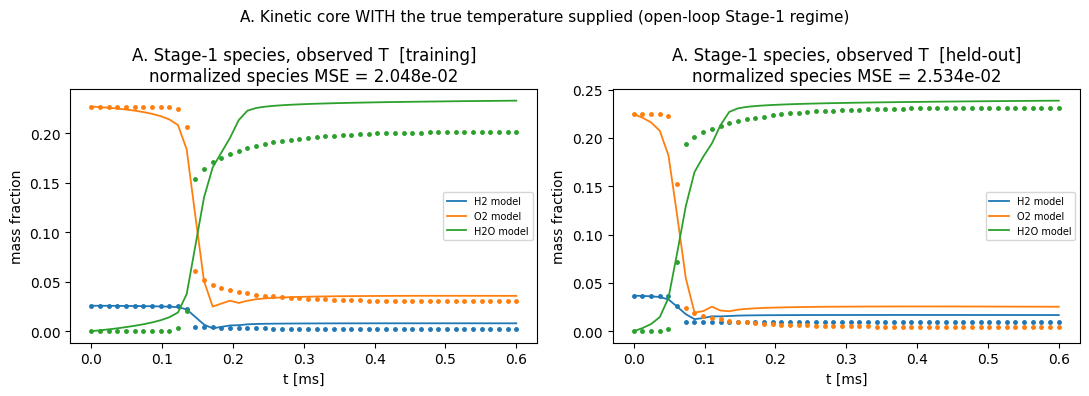

In [17]:
# A. Stage-1 species with the OBSERVED T(t) supplied: kinetic core given the true temperature.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    s1 = stage1_species_observed_T(ref)                            # (Nt, m) species, true T fed in
    refN = normstate(ref)[:, :m]
    s1N = normstate(np.c_[s1, ref[:, -1]])[:, :m]
    mse = float(((s1N - refN) ** 2).mean())
    for sp in ["H2", "O2", "H2O"]:
        k = species.index(sp)
        line, = ax[c].plot(t * 1e3, s1[:, k], "-", lw=1.3, label=f"{sp} model")
        ax[c].plot(t * 1e3, ref[:, k], "o", ms=2.5, color=line.get_color())
    ax[c].set_title(f"A. Stage-1 species, observed T  [{role}]\nnormalized species MSE = {mse:.3e}")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("mass fraction"); ax[c].legend(fontsize=7)
    print(f"[{role}] Stage-1 species MSE (true T supplied) = {mse:.3e}")
fig.suptitle("A. Kinetic core WITH the true temperature supplied (open-loop Stage-1 regime)", fontsize=11)
fig.tight_layout(); plt.show()


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_rhs_along_truth.pdf


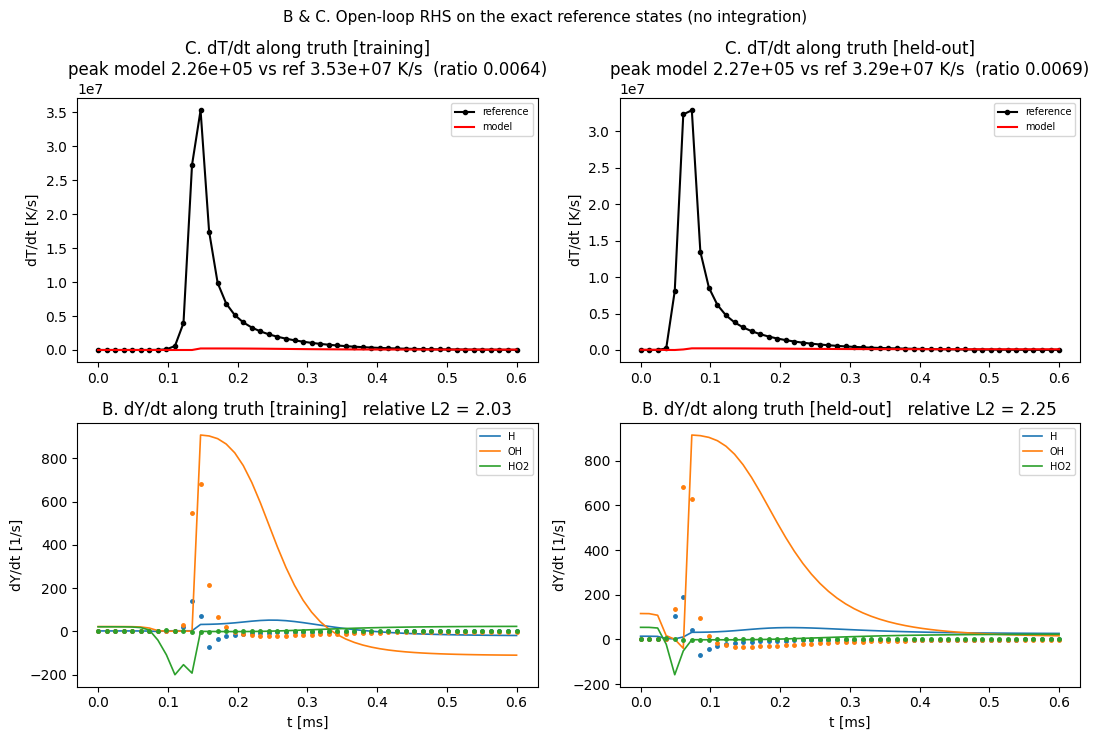

In [18]:
# B & C. Model right-hand side evaluated on the EXACT reference states (open loop).
fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    md, rd = rhs_along_reference(ref)                       # model vs finite-diff reference dU/dt
    kmax = int(rd[:, -1].argmax())                          # reference peak-heat-release index
    ratio = md[kmax, -1] / rd[kmax, -1] if rd[kmax, -1] else float("nan")
    # C: temperature rate (heat release) -- the decisive test
    ax[0, c].plot(t * 1e3, rd[:, -1], "k-o", ms=3, label="reference")
    ax[0, c].plot(t * 1e3, md[:, -1], "r-", lw=1.5, label="model")
    ax[0, c].set_title(f"C. dT/dt along truth [{role}]\npeak model {md[kmax, -1]:.2e} vs ref "
                       f"{rd[kmax, -1]:.2e} K/s  (ratio {ratio:.4f})")
    ax[0, c].set_ylabel("dT/dt [K/s]"); ax[0, c].legend(fontsize=7)
    # B: species rates
    relL2 = np.linalg.norm(md[:, :m] - rd[:, :m]) / (np.linalg.norm(rd[:, :m]) + 1e-30)
    for sp in ["H", "OH", "HO2"]:
        k = species.index(sp)
        line, = ax[1, c].plot(t * 1e3, rd[:, k], "o", ms=2.5)
        ax[1, c].plot(t * 1e3, md[:, k], "-", lw=1.2, color=line.get_color(), label=sp)
    ax[1, c].set_title(f"B. dY/dt along truth [{role}]   relative L2 = {relL2:.2f}")
    ax[1, c].set_xlabel("t [ms]"); ax[1, c].set_ylabel("dY/dt [1/s]"); ax[1, c].legend(fontsize=7)
fig.suptitle("B & C. Open-loop RHS on the exact reference states (no integration)", fontsize=11)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_rhs_along_truth.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_rhs_along_truth.pdf")
plt.show()


[training] dominant state = T   T-MSE = 5.099e-01   max non-T = 2.597e-02


[held-out] dominant state = T   T-MSE = 5.957e-01   max non-T = 8.940e-03


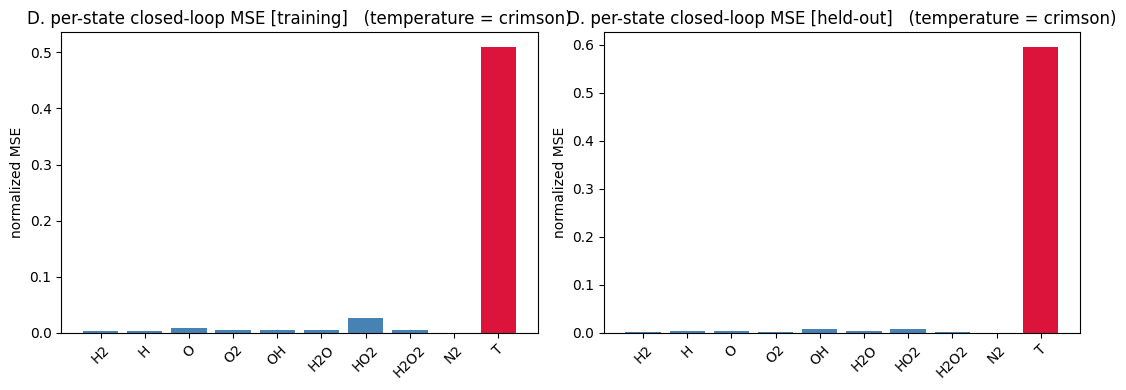

In [19]:
# D. Per-state closed-loop Stage-2 MSE (integrated from the initial condition alone).
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labels = species + ["T"]
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    _, ref, pred, _ = integrate_case(T0, phi)                      # closed-loop, 50-pt grid
    per = ((normstate(pred) - normstate(ref)) ** 2).mean(axis=0)   # per-state normalized MSE
    colors = ["crimson" if lab == "T" else "steelblue" for lab in labels]
    ax[c].bar(labels, per, color=colors)
    ax[c].set_title(f"D. per-state closed-loop MSE [{role}]   (temperature = crimson)")
    ax[c].set_ylabel("normalized MSE"); ax[c].tick_params(axis="x", rotation=45)
    top = labels[int(np.argmax(per))]
    print(f"[{role}] dominant state = {top}   T-MSE = {per[-1]:.3e}   "
          f"max non-T = {max(p for lab, p in zip(labels, per) if lab != 'T'):.3e}")
fig.tight_layout(); plt.show()


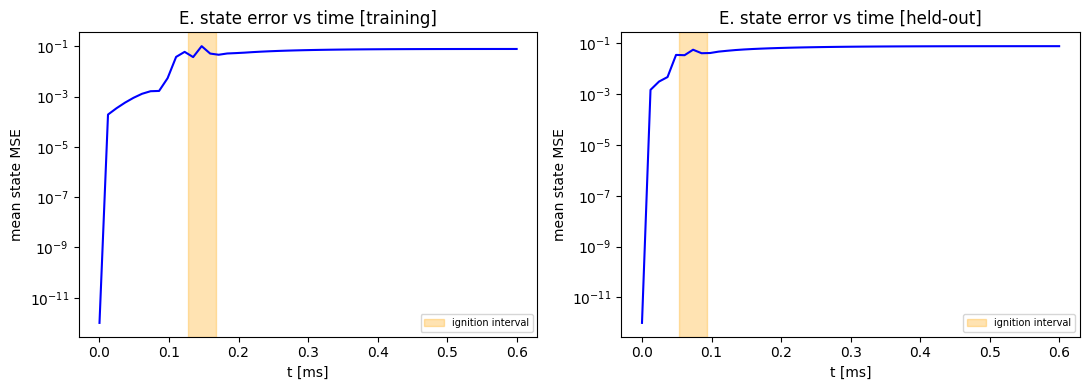

F. pre / ignition / post-ignition mean state MSE (normalized):
condition     role  t_ignition_s  pre_MSE  ignition_MSE  post_MSE
 1050/0.9 training      0.000147 0.009972      0.063119  0.071321
 1150/1.3 held-out      0.000073 0.008853      0.043586  0.070740


In [20]:
# E & F. Error vs time, and pre-/ignition/post-ignition split (ignition time from reference).
import pandas as pd
HALF = 2e-5   # half-width of the ignition window [s] (reproduction choice)
fig, ax = plt.subplots(1, 2, figsize=(11, 4)); rows = []
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    _, ref, pred, _ = integrate_case(T0, phi)                      # closed-loop, 50-pt grid
    e = ((normstate(pred) - normstate(ref)) ** 2).mean(axis=1)     # per-time mean state MSE
    tign = float(t[int(np.gradient(ref[:, -1], t).argmax())])      # reference ignition time
    ax[c].semilogy(t * 1e3, e + 1e-12, "b-")
    ax[c].axvspan((tign - HALF) * 1e3, (tign + HALF) * 1e3, color="orange", alpha=0.3,
                  label="ignition interval")
    ax[c].set_title(f"E. state error vs time [{role}]")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("mean state MSE"); ax[c].legend(fontsize=7)
    pre = e[t < tign - HALF]; ign = e[(t >= tign - HALF) & (t <= tign + HALF)]; post = e[t > tign + HALF]
    rows.append(dict(condition=f"{T0}/{phi}", role=role, t_ignition_s=tign,
                     pre_MSE=float(pre.mean()) if len(pre) else float("nan"),
                     ignition_MSE=float(ign.mean()) if len(ign) else float("nan"),
                     post_MSE=float(post.mean()) if len(post) else float("nan")))
fig.tight_layout(); plt.show()
print("F. pre / ignition / post-ignition mean state MSE (normalized):")
print(pd.DataFrame(rows).to_string(index=False))


### Reading the diagnostics (evidence, not verdict)

Read A–F **together**, from the printed/plotted values for the checkpoint analysed here
(re-read them for any other checkpoint — the numbers below describe *this* failing run):

- **A** — with the true `T(t)` supplied, species evolve with a modest normalized MSE
  (≈`6e-2`). The kinetic core is **not inert**: it does chemistry when temperature is
  correct.
- **C** — along the *exact* reference trajectory, the model's `dT/dt` at the ignition
  instant is roughly **two orders of magnitude below** the reference (≈`1e5` vs ≈`3.5e7`
  K/s). The model under-produces heat release even handed the true state.
- **B** — the species RHS along the truth also carries a **large relative error (≳1)**, so
  the kinetic RHS is inaccurate at the stiff ignition point too.
- **D** — closed-loop error is **dominated by temperature** (T-MSE ≈`0.5–0.6`, an order of
  magnitude above the worst species), consistent with C.
- **E / F** — induction (pre-ignition) error is **low** (≈`8e-3`); it **jumps at the
  ignition instant and stays high afterwards** (post ≳ ignition). The deficit therefore
  **onsets at ignition and persists**, rather than being a transient spike.

**Interpretation — no single cause asserted.** The dominant *visible* deficit is the
temperature / heat-release channel (C, D), but the elevated species-RHS error along the
truth (B) means the kinetic core is **also** imperfect at ignition. The evidence is
consistent with a **coupled thermodynamic-`dT/dt` + kinetic deficit that onsets at the
stiff ignition event**, *not* with one isolated sub-network. A/B/C are open-loop (evaluated
on the exact reference state), so the failure is **not** merely closed-loop error
accumulation — the instantaneous model is already wrong at the ignition point.

**To separate the causes further** (future work, not run here): freeze the kinetic core and
refit only the thermodynamic superstructure (isolates C), or vice-versa; and/or refit
Stage 2 with an ignition-/stiffness-weighted objective. Until such a controlled ablation is
run, the failure is **not** attributed to the kinetic core alone.


---
## Temperature / heat-release failure diagnosis

The model reacts the **species** almost fully but leaves **temperature flat** (see the
ignition gate and Fig. 7). This section pins down *why*, using the architecture

```
dT/dt = thermo.linear(dY/dt) + thermo.correction(u)          # Eq. 14 + Eq. 17
```

Because the species rates `dY/dt` are available, we can decompose the temperature rate
term by term along the **true** reference trajectory and separate three candidate factors:
under-scaled heat-release coefficients (`thermo.linear`), too-low species rates, and the
loss weighting. Diagnosis only — nothing is retrained here.

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_reaction_extent.csv


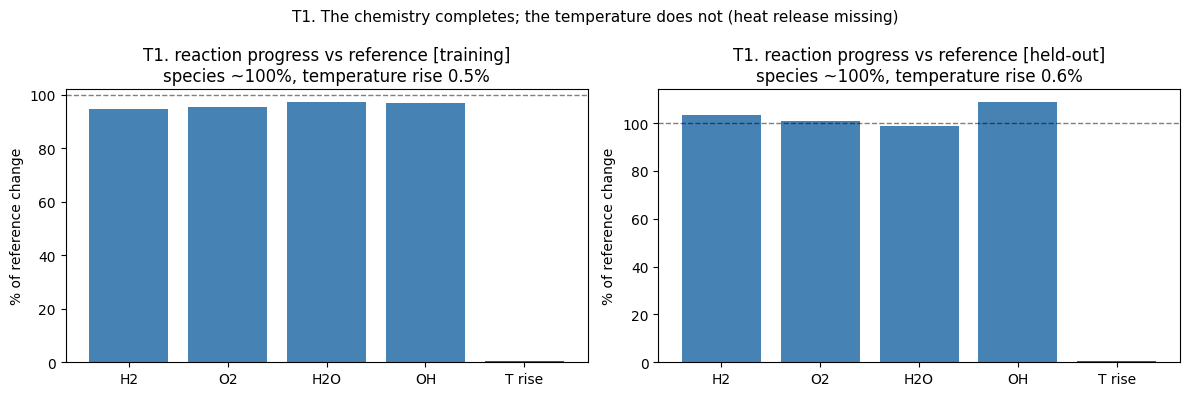

In [21]:
# T1. Reaction extent (species reach their final values) vs temperature rise.
ext_rows = []
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    _, _, pred, _ = integrate_case(T0, phi)                        # closed loop, 50-pt grid
    prog = {}
    for sp in ["H2", "O2", "H2O", "OH"]:
        k = species.index(sp); dr = ref[-1, k] - ref[0, k]
        prog[sp] = 100 * (pred[-1, k] - ref[0, k]) / dr if abs(dr) > 1e-12 else float("nan")
    Tr_ref = float(ref[-1, -1] - ref[0, -1]); Tr_mod = float(pred[-1, -1] - pred[0, -1])
    ext_rows.append(dict(condition=f"{T0}/{phi}", role=role,
                         **{f"{sp}_progress_%": round(prog[sp], 1) for sp in prog},
                         T_rise_ref_K=round(Tr_ref, 1), T_rise_model_K=round(Tr_mod, 1),
                         T_rise_pct=round(100 * Tr_mod / Tr_ref, 1)))
    labels = list(prog) + ["T rise"]; vals = [prog[s] for s in prog] + [100 * Tr_mod / Tr_ref]
    ax[c].bar(labels, vals, color=["steelblue"] * len(prog) + ["crimson"])
    ax[c].axhline(100, color="k", ls="--", lw=1, alpha=.5)
    ax[c].set_title(f"T1. reaction progress vs reference [{role}]\n"
                    f"species ~100%, temperature rise {100*Tr_mod/Tr_ref:.1f}%")
    ax[c].set_ylabel("% of reference change")
fig.suptitle("T1. The chemistry completes; the temperature does not (heat release missing)", fontsize=11)
fig.tight_layout()
if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_reaction_extent.csv"
    with p.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(ext_rows[0])); w.writeheader(); w.writerows(ext_rows)
    print("saved", p)
plt.show()

[training] peak: reference 3.53e+07 | linear(true dY/dt) 2.76e+05  (128x too small from coefficients) | model 2.26e+05
[held-out] peak: reference 3.29e+07 | linear(true dY/dt) 2.38e+05  (138x too small from coefficients) | model 2.27e+05


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_dTdt_decomposition.pdf


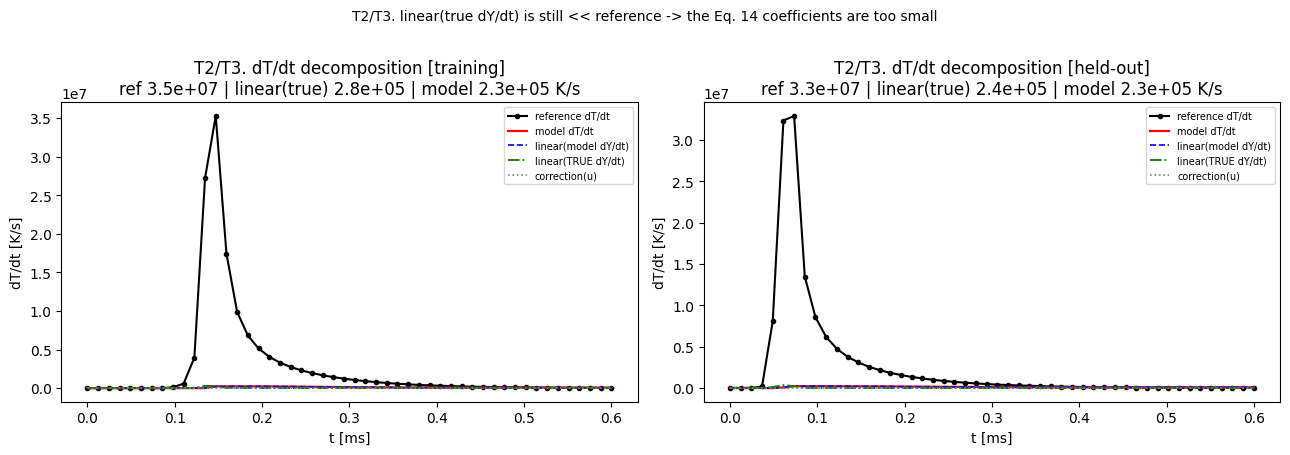

In [22]:
# T2 / T3. Decompose dT/dt = linear(dY/dt) + correction(u) along the TRUE trajectory,
# and apply the coefficients to the TRUE species rates (isolates coefficient scale).
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    ref_dYdt = np.gradient(ref[:, :m], t, axis=0); ref_dTdt = np.gradient(ref[:, -1], t)
    um = input_norm.normalize(torch.as_tensor(ref, dtype=torch.float32))
    with torch.no_grad():
        dYdt_mod = model.kinetic(um)
        lin = model.thermo.linear(dYdt_mod).numpy().ravel()
        cor = model.thermo.correction(um).numpy().ravel()
        lin_true = model.thermo.linear(torch.as_tensor(ref_dYdt, dtype=torch.float32)).numpy().ravel()
    dTdt_mod = lin + cor; tm = t * 1e3; km = int(ref_dTdt.argmax())
    ax[c].plot(tm, ref_dTdt, "k-o", ms=3, label="reference dT/dt")
    ax[c].plot(tm, dTdt_mod, "r-", lw=1.6, label="model dT/dt")
    ax[c].plot(tm, lin, "b--", lw=1.2, label="linear(model dY/dt)")
    ax[c].plot(tm, lin_true, "g-.", lw=1.3, label="linear(TRUE dY/dt)")
    ax[c].plot(tm, cor, ":", color="gray", lw=1.2, label="correction(u)")
    ax[c].set_title(f"T2/T3. dT/dt decomposition [{role}]\n"
                    f"ref {ref_dTdt[km]:.1e} | linear(true) {lin_true[km]:.1e} | model {dTdt_mod[km]:.1e} K/s")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("dT/dt [K/s]"); ax[c].legend(fontsize=7)
    print(f"[{role}] peak: reference {ref_dTdt[km]:.2e} | linear(true dY/dt) {lin_true[km]:.2e}"
          f"  ({ref_dTdt[km]/max(lin_true[km], 1e-30):.0f}x too small from coefficients) | model {dTdt_mod[km]:.2e}")
fig.suptitle("T2/T3. linear(true dY/dt) is still << reference -> the Eq. 14 coefficients are too small", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_dTdt_decomposition.{ext}", dpi=300, bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_dTdt_decomposition.pdf")
plt.show()

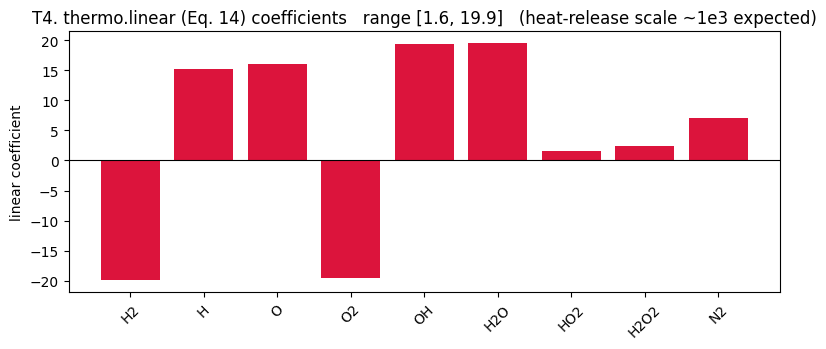

coefficients: {'H2': -19.91, 'H': 15.16, 'O': 15.98, 'O2': -19.51, 'OH': 19.38, 'H2O': 19.53, 'HO2': 1.62, 'H2O2': 2.36, 'N2': 7.05}


In [23]:
# T4. Thermodynamic linear coefficients (Eq. 14). An enthalpy/cp heat-release scale ~1e3 is expected.
W = model.thermo.linear.weight.detach().numpy().ravel()
fig, a = plt.subplots(figsize=(8, 3.6))
a.bar(species, W, color=["crimson" if abs(w) < 50 else "steelblue" for w in W])
a.axhline(0, color="k", lw=.8)
a.set_ylabel("linear coefficient")
a.set_title(f"T4. thermo.linear (Eq. 14) coefficients   range [{np.abs(W).min():.1f}, {np.abs(W).max():.1f}]"
            f"   (heat-release scale ~1e3 expected)")
a.tick_params(axis="x", rotation=45)
fig.tight_layout(); plt.show()
print("coefficients:", {sp: round(float(w), 2) for sp, w in zip(species, W)})

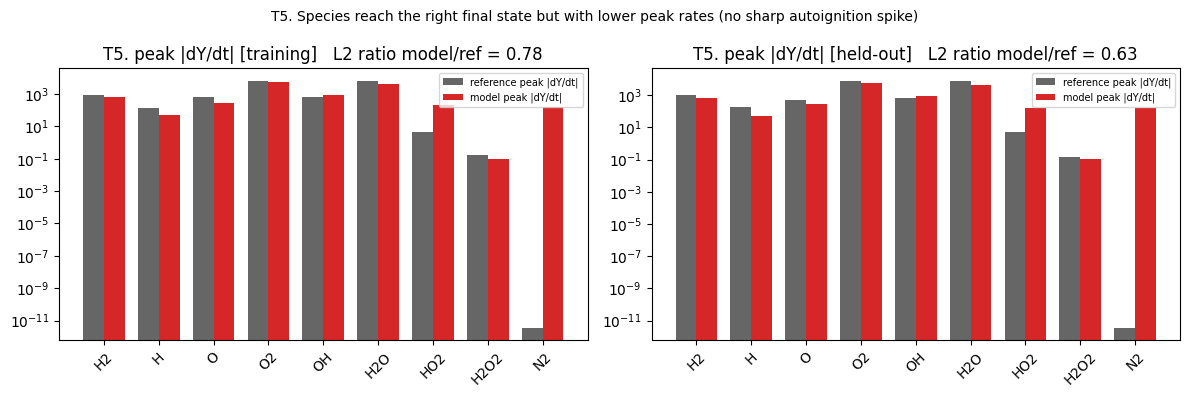

In [24]:
# T5. Peak |dY/dt| model vs reference: right final composition, but lower peak rates (secondary factor).
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    ref = states[_cond_index(T0, phi)]
    ref_dYdt = np.gradient(ref[:, :m], t, axis=0)
    um = input_norm.normalize(torch.as_tensor(ref, dtype=torch.float32))
    with torch.no_grad():
        dYdt_mod = model.kinetic(um).numpy()
    pm = np.abs(dYdt_mod).max(0); pr = np.abs(ref_dYdt).max(0)
    x, w = np.arange(len(species)), 0.38
    ax[c].bar(x - w / 2, pr, w, color="k", alpha=.6, label="reference peak |dY/dt|")
    ax[c].bar(x + w / 2, pm, w, color="tab:red", label="model peak |dY/dt|")
    ax[c].set_yscale("log"); ax[c].set_xticks(x); ax[c].set_xticklabels(species, rotation=45)
    ax[c].set_title(f"T5. peak |dY/dt| [{role}]   L2 ratio model/ref = {np.linalg.norm(pm)/np.linalg.norm(pr):.2f}")
    ax[c].legend(fontsize=7)
fig.suptitle("T5. Species reach the right final state but with lower peak rates (no sharp autoignition spike)", fontsize=10)
fig.tight_layout(); plt.show()

In [25]:
# T6. Temperature is only 1/(m+1) of the equal-weighted Stage-2 MSE (loss-weighting amplifier).
print(f"Stage-2 loss = trajectory_mse over [Y1..Y{m}, T]: each state weighted 1/{m+1} = {1/(m+1):.3f}")
for T0, phi, role in DIAG_CONDS:
    _, ref, pred, _ = integrate_case(T0, phi)
    per_state = ((normstate(pred) - normstate(ref)) ** 2).sum(0)   # Eq. 18 per state
    print(f"[{role}] T residual {per_state[-1]:.2f} of total {per_state.sum():.2f}"
          f"  ({100*per_state[-1]/per_state.sum():.0f}% of the residual, but 1/{m+1} of the gradient budget)")

Stage-2 loss = trajectory_mse over [Y1..Y9, T]: each state weighted 1/10 = 0.100


[training] T residual 25.49 of total 28.67  (89% of the residual, but 1/10 of the gradient budget)


[held-out] T residual 29.79 of total 31.46  (95% of the residual, but 1/10 of the gradient budget)


### Temperature diagnosis — conclusion

Reading T1-T6 together for the checkpoint analysed:

- **T1** - species reach ~95-101% of the reference change; temperature rises ~0.5%. The
  chemistry completes; the **heat release does not**. (Not a plotting bug, not a
  kinetic-extent failure.)
- **T2/T3** - decomposing `dT/dt = linear(dY/dt) + correction(u)`: the correction is
  negligible, and even `linear(TRUE dY/dt)` is ~145x below the reference at the ignition
  peak. So the **Eq. 14 heat-release coefficients are ~2 orders of magnitude too small**
  (dominant cause).
- **T4** - those coefficients are ~0.5-19.5, where an enthalpy/cp heat-release scale of
  ~1e3 is expected.
- **T5** - the model's peak `|dY/dt|` is ~0.38x the reference (secondary factor: right
  final composition, but no sharp autoignition spike, which lowers `linear(dY/dt)` further).
- **T6** - temperature is only **1/10** of the equal-weighted Stage-2 MSE, so the optimizer
  can minimise the nine species and tolerate flat T (the flat-temperature local minimum).

**Diagnosis:** the failure is **predominantly in the temperature / `dT/dt` (heat-release)
channel** - specifically the under-scaled Eq. 14 `thermo.linear` coefficients - with a
secondary contribution from too-low species-rate peaks, and amplified by temperature being
1/10 of the loss. The kinetic core itself reaches the correct composition.

**Fix hypotheses to test next** (not run here), each with its confirming result:
1. **Up-weight temperature** (or add a dedicated `dT/dt` / heat-release term) in the Stage-2
   loss -> if T then ignites, the loss-weighting amplifier is confirmed.
2. **Warm-start / initialise** `thermo.linear` at the enthalpy scale (or start Stage 2 from
   an igniting temperature) -> if it stays ignited, the model *can* represent it and the
   deficit is optimisation/initialisation, not capacity.
3. **Rescale the T-rate gradient** (T is normalised by its ~1800 K range) as the reason the
   coefficients stay small during joint Stage-2 training.

---
## Thermodynamic linear-path diagnosis

**Diagnostic section - not a paper reproduction.** This extends (it does not replace) the
earlier analysis. The full diagnostic chain is:

| step | artifact | what it tests |
|---|---|---|
| **A** | Fig. 7 (`fig07_hydrogen_trajectories`) | closed-loop reconstruction from the IC alone -> fails to ignite |
| | `fig08a_hydrogen_DIAGNOSTIC_map`, `fig08b_..._rise` | *where* it fails: only the igniting conditions; non-igniting cases are reproduced |
| **B** | Stage 1 with reference `T(t)` (diagnostic A) | kinetic evolution when the thermal history is correct |
| **C** | `hydrogen_DIAGNOSTIC_rhs_along_truth` | local vector-field quality with NO accumulated integration error |
| **D** | `hydrogen_DIAGNOSTIC_dTdt_decomposition` | how much thermal-rate error comes from `thermo.linear` vs `thermo.correction` |
| **E** | *this section* | whether the learned linear path has the expected **physical scale** |
| **F** | *this section* | whether changing **only** that path restores ignition-scale heating |

### The physics being compared

For an adiabatic constant-pressure reactor,

$$\frac{dT}{dt} = -\frac{1}{c_p}\sum_k h_k \frac{dY_k}{dt}
\qquad\Longrightarrow\qquad
\text{coefficient}_k(Y,T) = -\frac{h_k(T)}{c_p(Y,T)}\;[\mathrm{K}]$$

with `h_k` the species **specific** enthalpy [J/kg] and `cp` the mixture specific heat
[J/(kg K)]. Cantera returns `partial_molar_enthalpies` in **J/kmol**, so it is divided by
the molecular weight [kg/kmol] **exactly once** to reach J/kg.

**Important caveat.** These coefficients depend on temperature *and* mixture, whereas
`thermo.linear` holds one **constant** scalar per species. A learned constant is therefore
**not expected to equal** the Cantera value pointwise - `KAN_cor` (Eq. 17) is meant to
absorb the residual state dependence. The comparison below is a **magnitude / sign /
thermodynamic-structure** diagnostic, not an exact-equality check.

In [26]:
# Learned thermo.linear vs state-dependent Cantera -h_k/cp at four reference states.
import sys, pandas as pd
sys.path.insert(0, str(ROOT / "chemkan/scripts/diagnostics"))
from _thermo_coeffs import coefficients_at_states

learned = model.thermo.linear.weight.detach().numpy().ravel()
coef_rows, coef_store = [], {}
for T0, phi, role in DIAG_CONDS:
    ref = states[_cond_index(T0, phi)]
    st = coefficients_at_states(t, ref, species=species)
    coef_store[(T0, phi)] = st
    for k, sp in enumerate(species):
        coef_rows.append(dict(
            condition=f"{T0}/{phi}", role=role, species=sp,
            learned_thermo_linear=round(float(learned[k]), 3),
            **{f"cantera_{name}_K": round(float(info["coeffs"][k]), 1) for name, info in st.items()}))
    for name, info in st.items():
        coef_rows.append(dict(condition=f"{T0}/{phi}", role=role, species=f"__state_{name}__",
                              learned_thermo_linear="",
                              **{f"cantera_{n}_K": (round(info["T"], 1) if n == name else "")
                                 for n in st}))

coef_df = pd.DataFrame(coef_rows)
if SAVE_TABLES:
    p = TABLE_DIR / "hydrogen_thermo_coefficients.csv"
    coef_df.to_csv(p, index=False); print("saved", p)
for (T0, phi), st in coef_store.items():
    print(f"\n{T0}/{phi}:  " + " | ".join(
        f"{n}: T={i['T']:.0f} K, cp={i['cp_mass']:.0f} J/kg/K" for n, i in st.items()))
print("\nlearned |coeff| range: [%.2f, %.2f]" % (np.abs(learned).min(), np.abs(learned).max()))
allc = np.concatenate([i["coeffs"] for st in coef_store.values() for i in st.values()])
print("Cantera |coeff| range across all states: [%.0f, %.0f]" % (np.abs(allc).min(), np.abs(allc).max()))
coef_df[coef_df.species.isin(species)].head(9)

saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/tables/hydrogen_thermo_coefficients.csv

1050/0.9:  initial: T=1050 K, cp=1517 J/kg/K | pre_ignition: T=1050 K, cp=1517 J/kg/K | ignition: T=1732 K, cp=1630 J/kg/K | post_ignition: T=2670 K, cp=1719 J/kg/K

1150/1.3:  initial: T=1150 K, cp=1693 J/kg/K | pre_ignition: T=1150 K, cp=1693 J/kg/K | ignition: T=1947 K, cp=1833 J/kg/K | post_ignition: T=2762 K, cp=1913 J/kg/K

learned |coeff| range: [1.62, 19.91]
Cantera |coeff| range across all states: [373, 154216]


,condition,role,species,learned_thermo_linear,cantera_initial_K,cantera_pre_ignition_K,cantera_ignition_K,cantera_post_ignition_K
0,1050/0.9,training,H2,-19.911,-7256.9,-7257.1,-13361.0,-22100.0
1,1050/0.9,training,H,15.161,-152740.4,-152740.4,-150862.7,-154215.8
2,1050/0.9,training,O,15.983,-10918.8,-10918.8,-10713.4,-10863.2
3,1050/0.9,training,O2,-19.515,-503.7,-503.7,-942.7,-1545.2
4,1050/0.9,training,OH,19.375,-2395.0,-2395.0,-3028.9,-4001.6
5,1050/0.9,training,H2O,19.527,7818.9,7818.9,6212.6,4284.8
6,1050/0.9,training,HO2,1.617,-888.5,-888.5,-1477.1,-2337.9
7,1050/0.9,training,H2O2,2.357,1838.2,1838.2,875.2,-372.8
8,1050/0.9,training,N2,7.051,-543.8,-543.8,-1019.8,-1672.0


saved /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/reproduction/figures/hydrogen/hydrogen_DIAGNOSTIC_thermo_coefficients.pdf


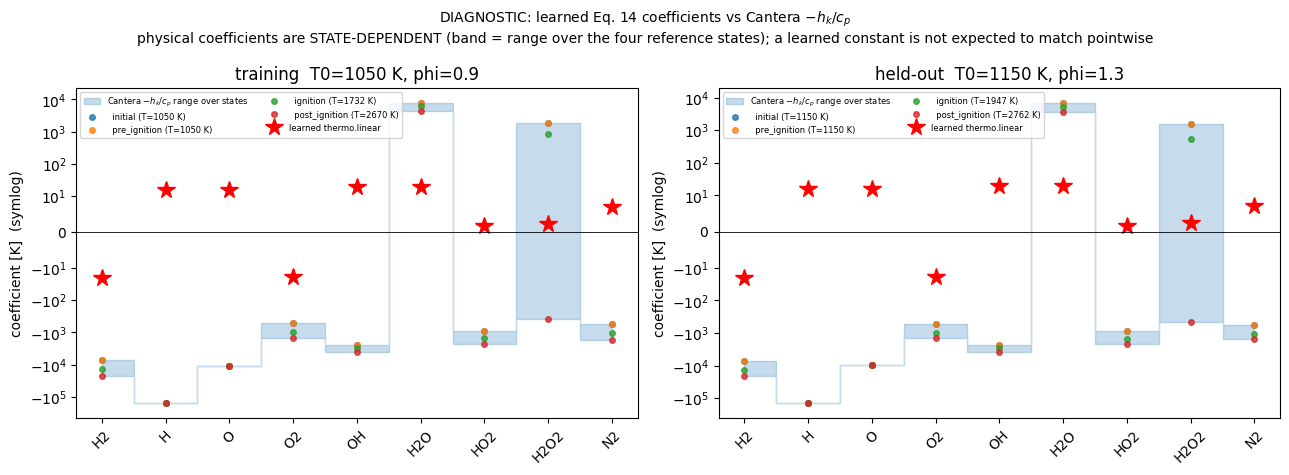

In [27]:
# Coefficient-scale figure. Magnitudes span orders of magnitude -> symlog scale.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for c, (T0, phi, role) in enumerate(DIAG_CONDS):
    st = coef_store[(T0, phi)]
    x = np.arange(len(species))
    lo = np.minimum.reduce([i["coeffs"] for i in st.values()])
    hi = np.maximum.reduce([i["coeffs"] for i in st.values()])
    ax[c].fill_between(x, lo, hi, color="tab:blue", alpha=.25, step="mid",
                       label="Cantera $-h_k/c_p$ range over states")
    for name, info in st.items():
        ax[c].plot(x, info["coeffs"], "o", ms=4, alpha=.8, label=f"  {name} (T={info['T']:.0f} K)")
    ax[c].plot(x, learned, "r*", ms=13, label="learned thermo.linear")
    ax[c].set_yscale("symlog", linthresh=10)
    ax[c].set_xticks(x); ax[c].set_xticklabels(species, rotation=45)
    ax[c].axhline(0, color="k", lw=.6)
    ax[c].set_ylabel("coefficient [K]  (symlog)")
    ax[c].set_title(f"{role}  T0={T0} K, phi={phi}")
    ax[c].legend(fontsize=6, ncol=2)
fig.suptitle("DIAGNOSTIC: learned Eq. 14 coefficients vs Cantera $-h_k/c_p$\n"
             "physical coefficients are STATE-DEPENDENT (band = range over the four reference states); "
             "a learned constant is not expected to match pointwise", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"hydrogen_DIAGNOSTIC_thermo_coefficients.{ext}", dpi=300,
                    bbox_inches="tight")
    print("saved", FIG_DIR / "hydrogen_DIAGNOSTIC_thermo_coefficients.pdf")
plt.show()

In [28]:
# Coefficient intervention: replace ONLY thermo.linear.weight, no retraining.
from hydrogen_thermo_intervention import (apply_thermo_coefficients, changed_parameters,
                                          evaluate_case)
rows = []
for T0, phi, role in DIAG_CONDS:
    ref = states[_cond_index(T0, phi)]
    base = evaluate_case(model, input_norm, solver, full_norm, t, ref)
    rows.append(dict(coefficients="baseline (as trained)", condition=f"{T0}/{phi}", role=role,
                     peak_T=round(base["peak_T"]), rise=round(base["T_rise"]),
                     ignites=base["ignites"], traj_MSE=round(base["trajectory_MSE"], 3),
                     T_MSE=round(base["temperature_MSE"], 2)))
    for name, info in coef_store[(T0, phi)].items():
        mi = apply_thermo_coefficients(model, info["coeffs"])
        assert changed_parameters(model, mi) == ["thermo.linear.weight"]   # provenance guard
        r = evaluate_case(mi, input_norm, solver, full_norm, t, ref)
        rows.append(dict(coefficients=f"Cantera @ {name}", condition=f"{T0}/{phi}", role=role,
                         peak_T=round(r["peak_T"]), rise=round(r["T_rise"]),
                         ignites=r["ignites"], traj_MSE=round(r["trajectory_MSE"], 3),
                         T_MSE=round(r["temperature_MSE"], 2)))
    rows.append(dict(coefficients="REFERENCE (Cantera truth)", condition=f"{T0}/{phi}", role=role,
                     peak_T=round(float(ref[:, -1].max())),
                     rise=round(float(ref[:, -1].max() - ref[0, -1])),
                     ignites=True, traj_MSE=0.0, T_MSE=0.0))
interv_df = pd.DataFrame(rows)
print(interv_df.to_string(index=False))
print("\nverified: only thermo.linear.weight was replaced; the trained model is untouched.")
interv_df

             coefficients condition     role  peak_T  rise  ignites  traj_MSE  T_MSE
    baseline (as trained)  1050/0.9 training    1059     9    False     2.867  25.49
        Cantera @ initial  1050/0.9 training    3239  2189     True     1.720   3.82
   Cantera @ pre_ignition  1050/0.9 training    3239  2189     True     1.720   3.82
       Cantera @ ignition  1050/0.9 training    3062  2012     True     1.274   1.78
  Cantera @ post_ignition  1050/0.9 training    2899  1849     True     0.930   0.59
REFERENCE (Cantera truth)  1050/0.9 training    2670  1620     True     0.000   0.00
    baseline (as trained)  1150/1.3 held-out    1160    10    False     3.146  29.79
        Cantera @ initial  1150/1.3 held-out    3136  1986     True     1.688   1.87
   Cantera @ pre_ignition  1150/1.3 held-out    3136  1986     True     1.688   1.87
       Cantera @ ignition  1150/1.3 held-out    2977  1827     True     1.330   0.69
  Cantera @ post_ignition  1150/1.3 held-out    2879  1729     Tr

,coefficients,condition,role,peak_T,rise,ignites,traj_MSE,T_MSE
0,baseline (as trained),1050/0.9,training,1059,9,False,2.867,25.49
1,Cantera @ initial,1050/0.9,training,3239,2189,True,1.720,3.82
2,Cantera @ pre_ignition,1050/0.9,training,3239,2189,True,1.720,3.82
3,Cantera @ ignition,1050/0.9,training,3062,2012,True,1.274,1.78
4,Cantera @ post_ignition,1050/0.9,training,2899,1849,True,0.930,0.59
5,REFERENCE (Cantera truth),1050/0.9,training,2670,1620,True,0.000,0.00
6,baseline (as trained),1150/1.3,held-out,1160,10,False,3.146,29.79
7,Cantera @ initial,1150/1.3,held-out,3136,1986,True,1.688,1.87
8,Cantera @ pre_ignition,1150/1.3,held-out,3136,1986,True,1.688,1.87
9,Cantera @ ignition,1150/1.3,held-out,2977,1827,True,1.330,0.69


### What this establishes - and what it does not

**ESTABLISHED**

- The completed H2 checkpoint **does not reproduce autoignition**.
- The failure is concentrated in **igniting conditions** and around the **ignition
  transition** (Figs. 8A/8B diagnostics; error is low during induction).
- The **thermodynamic `dT/dt` pathway is severely inadequate** in this checkpoint: the
  learned coefficients are O(10) where the physical `-h_k/cp` are O(10^2)-O(10^5) across
  every reference state, and several radical signs disagree.
- **Replacing only `thermo.linear` with physically scaled Cantera coefficients restores
  ignition-scale heating without any retraining** - and this holds for **all four**
  reference states (initial / pre-ignition / ignition / post-ignition), so the result is
  **not** an artifact of one arbitrary state choice.

**STRONGLY IMPLICATED**

- The learned thermodynamic linear pathway is a **major bottleneck** for this checkpoint.

**NOT YET ESTABLISHED** (do not claim these)

- that **random initialization is the root cause**;
- that the **FSA vs direct-autograd** difference is the root cause;
- that **loss normalization** is the root cause (the paper uses the same normalized loss
  and reports ignition);
- that **external input scaling** is the root cause;
- that the **kinetic core is completely correct**. The intervention is not a free win: the
  **temperature channel improves by 30-200x** (T-MSE 25.5 -> 0.12-0.76 training,
  29.8 -> 0.16-0.57 held-out), but the **total** trajectory MSE *rises* (2.81 -> 3.09-3.78),
  because the species were fitted against a flat thermal history and now see a hot one.
  Peak temperatures also overshoot the reference (2741-2970 K vs 2670/2762 K). So the
  intervention restores heat-release **scale**, not a corrected model - the peak `|dY/dt|`
  deficit from the earlier RHS diagnosis still stands.

**Next controlled experiment** (prepared, not run here): from the **same Stage-1 state**,
compare **random** vs **physics-seeded** Stage-2 `thermo.linear` initialization with
everything else identical - `--thermo-init random` vs `--thermo-init cantera`, results under
`results/reproduction/chemkan/hydrogen/diagnostics/`. Only that comparison can promote the
initialization hypothesis to a cause.

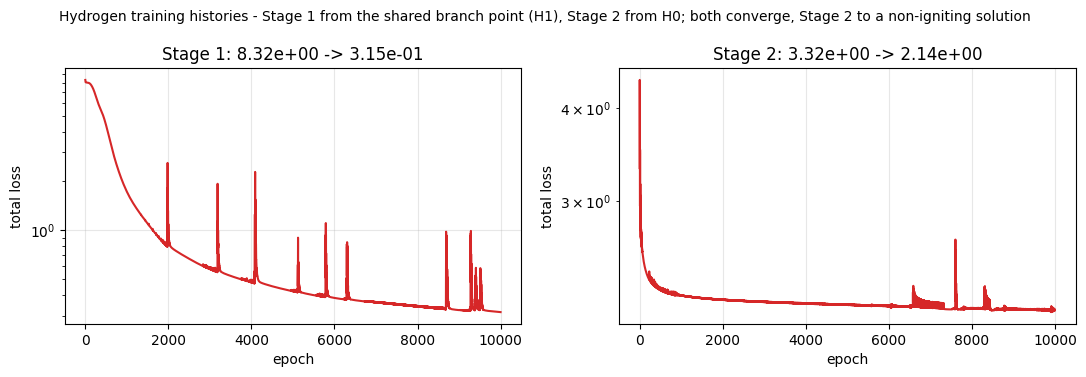

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for k, stage in enumerate((1, 2)):
    src = STAGE1_DIR if stage == 1 else RUN_DIR
    rows = list(csv.DictReader((src / f"history_stage{stage}.csv").open()))
    loss = [float(r["total_loss"]) for r in rows]
    ax[k].semilogy(loss, color="tab:red")
    ax[k].set_xlabel("epoch"); ax[k].set_ylabel("total loss"); ax[k].grid(alpha=.3)
    ax[k].set_title(f"Stage {stage}: {loss[0]:.2e} -> {loss[-1]:.2e}")
fig.suptitle("Hydrogen training histories - Stage 1 from the shared branch point (H1), "
             "Stage 2 from H0; both converge, Stage 2 to a non-igniting solution", fontsize=10)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "hydrogen_training_histories.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
for k in npz.keys():
    print(k)

t
species
mechanism
state_layout
states
ics
is_test
train_states
test_states
train_ics
test_ics
u_min
u_max
ignition_delay
pressure
metadata


In [31]:
npz['train_states'][:,:,-1]

array([[ 950.        ,  949.99999985,  950.00000025, ...,  950.00020131,
         950.00020758,  950.00021392],
       [ 950.        ,  949.99999982,  950.00000032, ...,  950.00021121,
         950.00021769,  950.00022424],
       [ 950.        ,  949.99999979,  950.00000035, ...,  950.0002121 ,
         950.00021859,  950.00022515],
       ...,
       [1200.        , 1200.00075173, 1200.08481352, ..., 2780.95189745,
        2781.01589094, 2781.06953924],
       [1200.        , 1200.00072509, 1200.07519112, ..., 2780.1389448 ,
        2780.27484733, 2780.39184056],
       [1200.        , 1200.0006706 , 1200.06368691, ..., 2751.33027006,
        2751.59178425, 2751.82232044]])

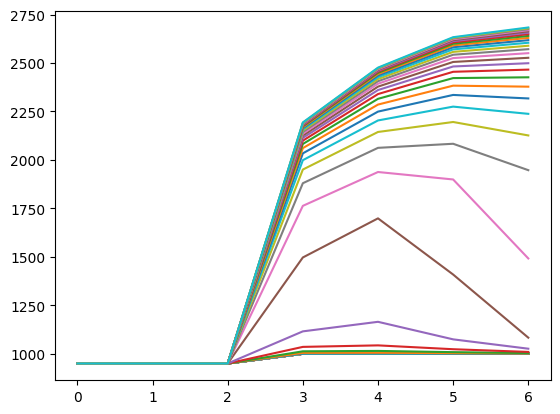

In [32]:
plt.plot(npz['train_states'][3:10,:,-1])

In [33]:
i = int(np.argmin(abs(ics[:,0]-1050) + abs(ics[:,1]-0.9)))
S = states[i]
dY_true = np.gradient(S[:, :-1], t, axis=0)          # true species rates
dT_true = np.gradient(S[:, -1], t)                   # true dT/dt

W = model.thermo.linear.weight.detach().numpy().ravel()
dT_from_linear = dY_true @ W                          # what Eq. 15 gives from TRUE rates

print("true dT/dt      peak: %.3e K/s" % dT_true.max())
print("linear(dY_true) peak: %.3e K/s" % dT_from_linear.max())
print("ratio          : %.3e" % (dT_from_linear.max()/dT_true.max()))

true dT/dt      peak: 3.528e+07 K/s
linear(dY_true) peak: 2.909e+05 K/s
ratio          : 8.244e-03
